# Strategic Classification: Non-Backdoor Poisoning

Non-backdoor poisoning using the epsilon-delta constraint framework.

**Threat model:** Epsilon fraction of agents respond adversarially. Adversarial shifts
are clamped to an **Linf delta-ball** around the honest best-response position.

**Attacks:**
- **Cluster Shift:** shift toward opposing class mean in strategic feature space
- **Shadow Model:** train shadow logreg on observed data, shift toward decision boundary

Compares clean vs poisoned for RGD and PerfGD across LogReg + Linear and MLP + Gradient.

In [19]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import sys
import os

cwd = os.getcwd()  # poison-perf/strategic/
root = os.path.dirname(cwd)  # poison-perf/
sys.path.append(root)

from utils.algorithms import RGD, PerfGD
from strategic.strategic_setup import setup_strategic_classification, _mlp_forward
from utils.data_prep import load_data
from response import make_strategic_poison, cluster_shift_attack, shadow_model_attack

## Load Data

In [20]:
data_dir = "data/GiveMeSomeCredit"
data_file = "cs-training.csv"
data_path = os.path.join(root, data_dir, data_file)
X_np, Y_np, data = load_data(data_path)

n_samples, d_plus_bias = X_np.shape
print("n_samples =", n_samples, ", d+1 (with bias) =", d_plus_bias)

strat_features = np.array([1, 6, 8]) - 1  # 0-indexed
print("\nStrategic features:")
for i, feature in enumerate(strat_features):
    print(f"  {i}: [{feature}] {data.columns[feature + 1]}")

device = torch.device("cpu")
X_full = torch.from_numpy(X_np).float().to(device)
Y_full = torch.from_numpy(Y_np).float().to(device)

lam = 1.0 / n_samples
alpha_strat = 1.0

n_samples = 18357 , d+1 (with bias) = 11

Strategic features:
  0: [0] RevolvingUtilizationOfUnsecuredLines
  1: [5] NumberOfOpenCreditLinesAndLoans
  2: [7] NumberRealEstateLoansOrLines


## Configuration

In [21]:
n = n_samples
max_iter = 100

# Smoothness-based learning rate
smoothness = (X_full ** 2).sum().item() / (4.0 * n_samples)
eta_logreg = 2.0 / (smoothness + 2.0 * lam)
eta_mlp = 0.2

proj_theta = lambda t: t

MLP_HIDDEN_DIMS = [32, 16]
d = X_full.shape[1] - 1

# Poisoning parameters. For continuous features, poison_delta is a robust-scale
# multiplier; for count features, poison_delta=1.0 means +/-1 original count.
poison_epsilon = 0.3
poison_delta = 10000.0

# load_data() z-scores every feature with sklearn.preprocessing.scale before training.
# Keep raw moments and robust scales here so bounds are interpreted in original CSV
# units, then converted back to z-score units for the model-space clamp.
raw_features = data.drop("SeriousDlqin2yrs", axis=1).to_numpy()
raw_feature_means = raw_features.mean(axis=0)
raw_feature_stds = raw_features.std(axis=0)

def robust_iqr_scale(raw_col):
    """IQR-based robust scale estimate, in original CSV units."""
    q25, q75 = np.percentile(raw_col, [25, 75])
    return max(float((q75 - q25) / 1.349), 1e-12)

raw_feature_iqr_scales = np.array([
    robust_iqr_scale(raw_features[:, j])
    for j in range(raw_features.shape[1])
])

# Only the count-valued line-of-credit strategic features are quantized.
# strat_features = [RevolvingUtilizationOfUnsecuredLines, NumberOfOpenCreditLinesAndLoans,
#                   NumberRealEstateLoansOrLines]
# Local index 0 (RevolvingUtilizationOfUnsecuredLines) intentionally stays continuous.
discrete_strat_local_idxs = [1, 2]
response_quantization_steps = {
    local_idx: 1.0 / float(raw_feature_stds[strat_features[local_idx]])
    for local_idx in discrete_strat_local_idxs
}
response_max_delta = response_quantization_steps.copy()  # count features: -1, 0, or +1 actual credit line
response_min_values = {
    0: float((0.0 - raw_feature_means[strat_features[0]]) / raw_feature_stds[strat_features[0]])
}  # RevolvingUtilizationOfUnsecuredLines cannot go below raw 0

def make_poison_delta_by_feature(delta_multiplier):
    """Return per-strategic-feature Linf bounds in standardized model units."""
    delta_multiplier = float(delta_multiplier)
    deltas = np.zeros(len(strat_features), dtype=np.float32)
    for local_idx, col in enumerate(strat_features):
        if local_idx in discrete_strat_local_idxs:
            # Cap count-valued poisoning at +/-1 original count even when sweeps use larger deltas.
            deltas[local_idx] = min(delta_multiplier, 1.0) * response_quantization_steps[local_idx]
        else:
            # Continuous heavy-tailed features get an IQR-derived raw bound, then z-score conversion.
            deltas[local_idx] = delta_multiplier * raw_feature_iqr_scales[col] / raw_feature_stds[col]
    return torch.tensor(deltas, dtype=torch.float32)

poison_delta_by_feature = make_poison_delta_by_feature(poison_delta)
# Also cap the continuous strategic response by the same robust raw movement.
response_max_delta[0] = float(poison_delta_by_feature[0])

def to_raw_feature_values(x_standardized, feature_col):
    """Convert one standardized feature column back to the original CSV scale."""
    return x_standardized * raw_feature_stds[feature_col] + raw_feature_means[feature_col]

def feature_axis_label(feature_col):
    name = data.columns[feature_col + 1]
    if name == "RevolvingUtilizationOfUnsecuredLines":
        return "Original CSV utilization ratio (1.0 = 100%)"
    if feature_col in strat_features[discrete_strat_local_idxs]:
        return "Original CSV count"
    return "Original CSV value"

def set_feature_axis_format(ax, feature_col):
    if feature_col in strat_features[discrete_strat_local_idxs]:
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

print(f"eta_logreg = {eta_logreg:.4f}, eta_mlp = {eta_mlp}")
print(f"poison_epsilon = {poison_epsilon}, poison_delta = {poison_delta} robust/raw-count units")
print("Configured per-feature poison bounds. These are enforced in z-score space:")
for local_idx, col in enumerate(strat_features):
    feature_name = data.columns[col + 1]
    z_delta = float(poison_delta_by_feature[local_idx])
    raw_delta = z_delta * raw_feature_stds[col]
    if feature_name == "RevolvingUtilizationOfUnsecuredLines":
        print(f"  {feature_name}: +/-{z_delta:.6f} z, +/-{raw_delta:.3f} utilization ratio "
              f"(+/-{100 * raw_delta:.1f} percentage points); IQR scale={raw_feature_iqr_scales[col]:.3f}")
    elif local_idx in discrete_strat_local_idxs:
        print(f"  {feature_name}: +/-{z_delta:.6f} z, +/-{raw_delta:.0f} raw count")
    else:
        print(f"  {feature_name}: +/-{z_delta:.6f} z, +/-{raw_delta:.3f} raw units")
print("Discrete strategic movement steps:")
for local_idx, step in response_quantization_steps.items():
    feature_name = data.columns[strat_features[local_idx] + 1]
    print(f"  {feature_name}: standardized step={step:.4f}, max move=+/-1 raw count")

# Create poison functions
cluster_fn = make_strategic_poison(
    attack_fn=cluster_shift_attack, strat_features=strat_features.tolist(),
    epsilon=poison_epsilon, delta=poison_delta_by_feature, selection="per_class",
    quantization_steps=response_quantization_steps,
    quantization_max_delta=response_max_delta,
    min_values=response_min_values)

shadow_fn = make_strategic_poison(
    attack_fn=shadow_model_attack, strat_features=strat_features.tolist(),
    epsilon=poison_epsilon, delta=poison_delta_by_feature, selection="per_class",
    quantization_steps=response_quantization_steps,
    quantization_max_delta=response_max_delta,
    min_values=response_min_values, shift_scale=10.0)

attacks = {"Cluster Shift": cluster_fn, "Shadow Model": shadow_fn}
print(f"Attacks: {list(attacks.keys())}")


eta_logreg = 0.4286, eta_mlp = 0.2
poison_epsilon = 0.3, poison_delta = 10000.0 robust/raw-count units
Configured per-feature poison bounds. These are enforced in z-score space:
  RevolvingUtilizationOfUnsecuredLines: +/-15.698615 z, +/-4035.166 utilization ratio (+/-403516.6 percentage points); IQR scale=0.404
  NumberOfOpenCreditLinesAndLoans: +/-0.193318 z, +/-1 raw count
  NumberRealEstateLoansOrLines: +/-0.870119 z, +/-1 raw count
Discrete strategic movement steps:
  NumberOfOpenCreditLinesAndLoans: standardized step=0.1933, max move=+/-1 raw count
  NumberRealEstateLoansOrLines: standardized step=0.8701, max move=+/-1 raw count
Attacks: ['Cluster Shift', 'Shadow Model']


## Setup Both Models

In [22]:
# LogReg + Linear
mu_f_lr, sigma_lr, D_theta_lr, loss_lr, theta_0_lr, grad2_est_lr, f_hat_lr = setup_strategic_classification(
    X_base=X_full, Y_base=Y_full, strat_features=strat_features.tolist(),
    alpha=alpha_strat, lam=lam, classifier="logreg", performativity="linear", perfGD=True,
    response_quantization_steps=response_quantization_steps, response_max_delta=response_max_delta,
    response_min_values=response_min_values,
)
print(f"LogReg theta_0: {theta_0_lr.shape} ({theta_0_lr.numel()} params)")

# MLP + Gradient
mu_f_mlp, sigma_mlp, D_theta_mlp, loss_mlp, theta_0_mlp, grad2_est_mlp, f_hat_mlp = setup_strategic_classification(
    X_base=X_full, Y_base=Y_full, strat_features=strat_features.tolist(),
    alpha=alpha_strat, lam=lam, classifier="mlp", performativity="gradient",
    perfGD=True, hidden_dims=MLP_HIDDEN_DIMS,
    response_quantization_steps=response_quantization_steps, response_max_delta=response_max_delta,
    response_min_values=response_min_values,
)
print(f"MLP theta_0: {theta_0_mlp.shape} ({theta_0_mlp.numel()} params)")

def compute_accuracy(theta, D_theta, classifier, hidden_dims, d, n_eval):
    """Compute classification accuracy on strategically shifted samples from D_theta."""
    z = D_theta(theta, n_eval)
    with torch.no_grad():
        x = z[:-1, :]
        y = z[-1, :]
        if classifier == "logreg":
            logits = theta[:-1] @ x + theta[-1]
        elif classifier == "mlp":
            logits = _mlp_forward(x.T, theta, d, hidden_dims)
        preds = (logits > 0).float()
        return (preds == y).float().mean().item()

models = {
    "LogReg + Linear": {
        "D_theta": D_theta_lr, "loss": loss_lr, "theta_0": theta_0_lr,
        "grad2_est": grad2_est_lr, "f_hat": f_hat_lr, "eta": eta_logreg,
        "classifier": "logreg", "hidden_dims": MLP_HIDDEN_DIMS,
    },
    "MLP + Gradient": {
        "D_theta": D_theta_mlp, "loss": loss_mlp, "theta_0": theta_0_mlp,
        "grad2_est": grad2_est_mlp, "f_hat": f_hat_mlp, "eta": eta_mlp,
        "classifier": "mlp", "hidden_dims": MLP_HIDDEN_DIMS,
    },
}


LogReg theta_0: torch.Size([11]) (11 params)
MLP theta_0: torch.Size([897]) (897 params)


## Run All Experiments (Clean vs Poisoned)

In [23]:
results = {}

for model_name, m in models.items():
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")

    D_theta = m["D_theta"]
    loss_fn = m["loss"]
    theta_0 = m["theta_0"]
    eta = m["eta"]

    # Clean RGD
    print("  RGD Clean...", end=" ")
    th_rc, all_th_rc, losses_rc = RGD(
        D_theta=D_theta, loss=loss_fn, theta_0=theta_0.clone(),
        n=n, eta=eta, max_iter=max_iter, proj_theta=proj_theta, return_losses=True)
    print(f"loss={losses_rc[-1]:.4f}")

    # Clean PerfGD
    print("  PerfGD Clean...", end=" ")
    th_pc, all_th_pc, losses_pc = PerfGD(
        f_hat=m["f_hat"], grad2_est=m["grad2_est"], D_theta=D_theta, loss=loss_fn,
        theta_0=theta_0.clone(), n=n, eta=eta, max_iter=max_iter,
        proj_theta=proj_theta, return_losses=True)
    print(f"loss={losses_pc[-1]:.4f}")

    theta0 = theta_0.detach().clone()

    for attack_name, poison_fn in attacks.items():
        key = f"{model_name} | {attack_name}"
        print(f"  {attack_name}:", end="")

        # Poisoned RGD
        print(" RGD...", end="")
        th_rp, all_th_rp, losses_rp = RGD(
            D_theta=D_theta, loss=loss_fn, theta_0=theta_0.clone(),
            n=n, eta=eta, max_iter=max_iter, proj_theta=proj_theta, return_losses=True,
            poison_function=poison_fn)
        print(f"{losses_rp[-1]:.4f}", end="")

        # Poisoned PerfGD
        print(" PerfGD...", end="")
        th_pp, all_th_pp, losses_pp = PerfGD(
            f_hat=m["f_hat"], grad2_est=m["grad2_est"], D_theta=D_theta, loss=loss_fn,
            theta_0=theta_0.clone(), n=n, eta=eta, max_iter=max_iter,
            proj_theta=proj_theta, return_losses=True,
            poison_function=poison_fn)
        print(f"{losses_pp[-1]:.4f}")

        results[key] = {
            "model": model_name, "attack": attack_name,
            "rgd_clean_losses": losses_rc, "rgd_poison_losses": losses_rp,
            "pgd_clean_losses": losses_pc, "pgd_poison_losses": losses_pp,
            "rgd_clean_theta": th_rc.detach(), "rgd_poison_theta": th_rp.detach(),
            "pgd_clean_theta": th_pc.detach(), "pgd_poison_theta": th_pp.detach(),
            "all_theta_rgd_clean": all_th_rc, "all_theta_rgd_poison": all_th_rp,
            "all_theta_pgd_clean": all_th_pc, "all_theta_pgd_poison": all_th_pp,
            "theta_0": theta0,
            "rgd_clean_diffs": [(t - theta0).norm().item() for t in all_th_rc],
            "rgd_poison_diffs": [(t - theta0).norm().item() for t in all_th_rp],
            "pgd_clean_diffs": [(t - theta0).norm().item() for t in all_th_pc],
            "pgd_poison_diffs": [(t - theta0).norm().item() for t in all_th_pp],
            "rgd_divergence": [torch.norm(c - p).item() for c, p in zip(all_th_rc, all_th_rp)],
            "pgd_divergence": [torch.norm(c - p).item() for c, p in zip(all_th_pc, all_th_pp)],
            "rgd_clean_accs": [compute_accuracy(t, D_theta, m["classifier"], m["hidden_dims"], d, n) for t in all_th_rc],
            "rgd_poison_accs": [compute_accuracy(t, D_theta, m["classifier"], m["hidden_dims"], d, n) for t in all_th_rp],
            "pgd_clean_accs": [compute_accuracy(t, D_theta, m["classifier"], m["hidden_dims"], d, n) for t in all_th_pc],
            "pgd_poison_accs": [compute_accuracy(t, D_theta, m["classifier"], m["hidden_dims"], d, n) for t in all_th_pp],
        }

print("\nDone.")


  LogReg + Linear
  RGD Clean... loss=0.6193
  PerfGD Clean... loss=0.6231
  Cluster Shift: RGD...0.6169 PerfGD...0.6174
  Shadow Model: RGD...0.6175 PerfGD...1.2025

  MLP + Gradient
  RGD Clean... loss=0.5448
  PerfGD Clean... loss=0.5442
  Cluster Shift: RGD...0.5449 PerfGD...0.5437
  Shadow Model: RGD...0.5460 PerfGD...0.5495

Done.


## Per-Model: Loss and Parameter Displacement

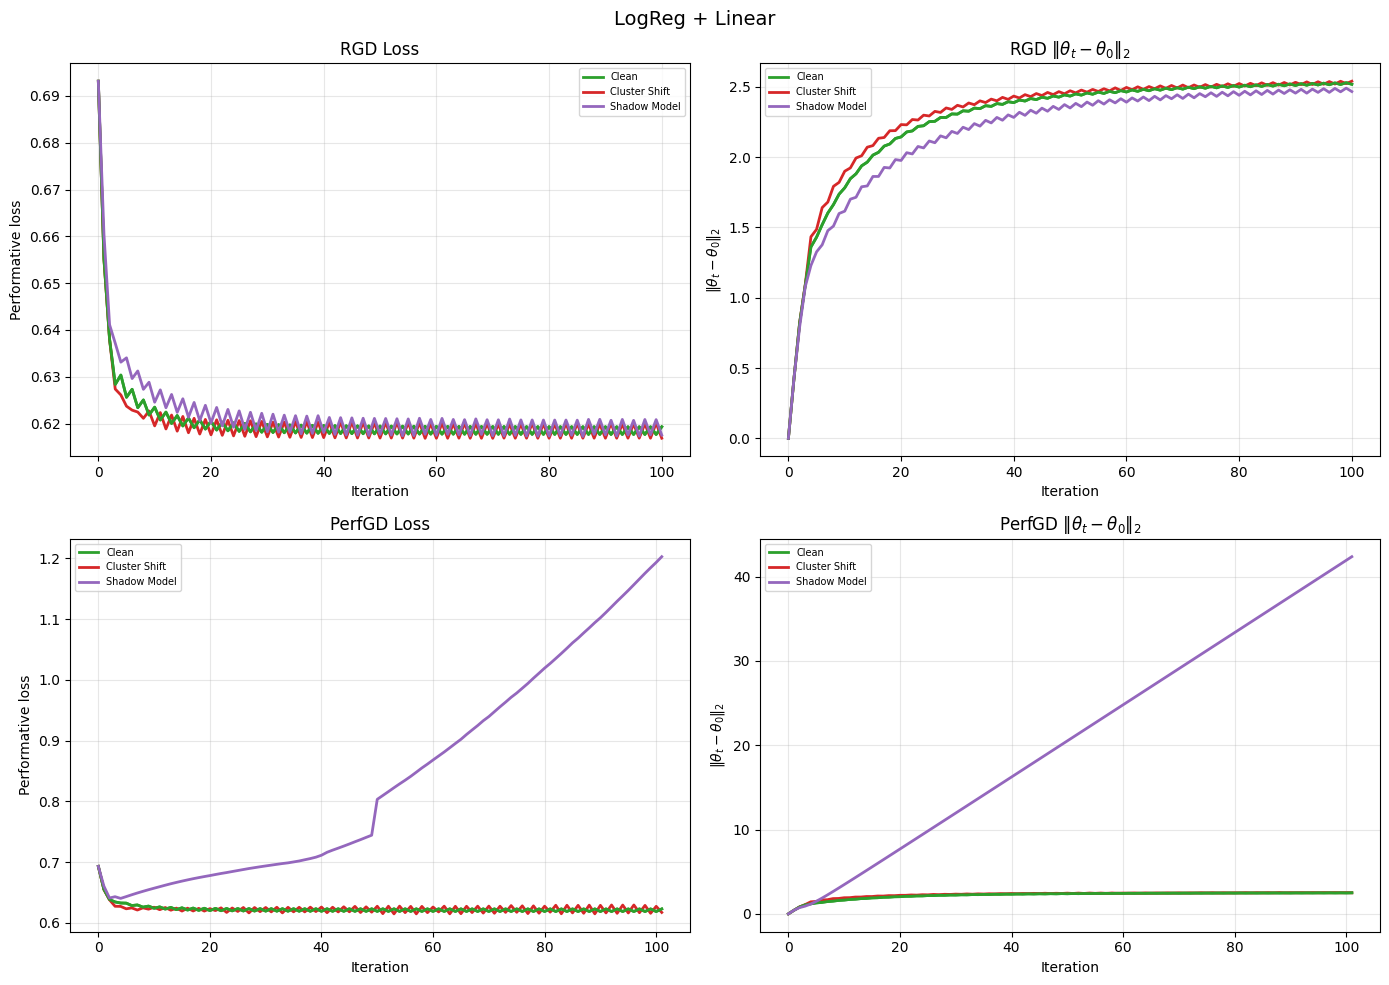

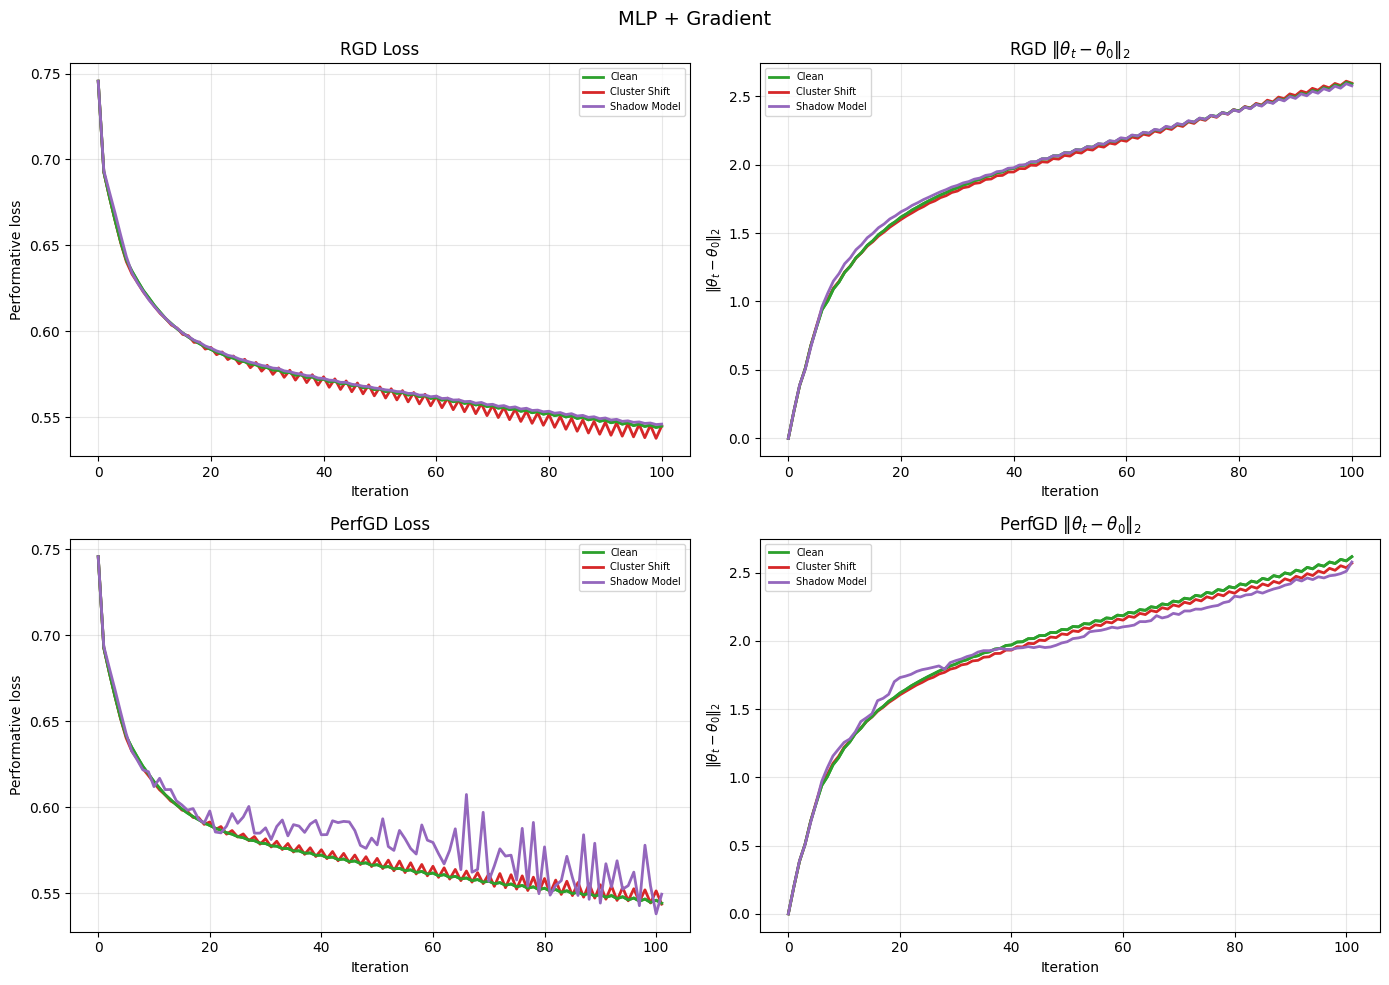

In [24]:
for model_name in models:
    model_results = {k: v for k, v in results.items() if v["model"] == model_name}
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(model_name, fontsize=14)

    attack_colors = {"Cluster Shift": "tab:red", "Shadow Model": "tab:purple"}

    for key, res in model_results.items():
        attack = res["attack"]
        c = attack_colors[attack]

        # RGD Loss
        axes[0, 0].plot(res["rgd_clean_losses"], color="tab:green", linewidth=2, label="Clean" if attack == "Cluster Shift" else None)
        axes[0, 0].plot(res["rgd_poison_losses"], color=c, linewidth=2, label=attack)

        # RGD Theta diff
        axes[0, 1].plot(res["rgd_clean_diffs"], color="tab:green", linewidth=2, label="Clean" if attack == "Cluster Shift" else None)
        axes[0, 1].plot(res["rgd_poison_diffs"], color=c, linewidth=2, label=attack)

        # PerfGD Loss
        axes[1, 0].plot(res["pgd_clean_losses"], color="tab:green", linewidth=2, label="Clean" if attack == "Cluster Shift" else None)
        axes[1, 0].plot(res["pgd_poison_losses"], color=c, linewidth=2, label=attack)

        # PerfGD Theta diff
        axes[1, 1].plot(res["pgd_clean_diffs"], color="tab:green", linewidth=2, label="Clean" if attack == "Cluster Shift" else None)
        axes[1, 1].plot(res["pgd_poison_diffs"], color=c, linewidth=2, label=attack)

    axes[0, 0].set_title("RGD Loss"); axes[0, 0].set_ylabel("Performative loss")
    axes[0, 1].set_title(r"RGD $\|\theta_t - \theta_0\|_2$"); axes[0, 1].set_ylabel(r"$\|\theta_t - \theta_0\|_2$")
    axes[1, 0].set_title("PerfGD Loss"); axes[1, 0].set_ylabel("Performative loss")
    axes[1, 1].set_title(r"PerfGD $\|\theta_t - \theta_0\|_2$"); axes[1, 1].set_ylabel(r"$\|\theta_t - \theta_0\|_2$")
    for ax in axes.flat:
        ax.set_xlabel("Iteration"); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Cross-Model Comparison: LogReg vs MLP

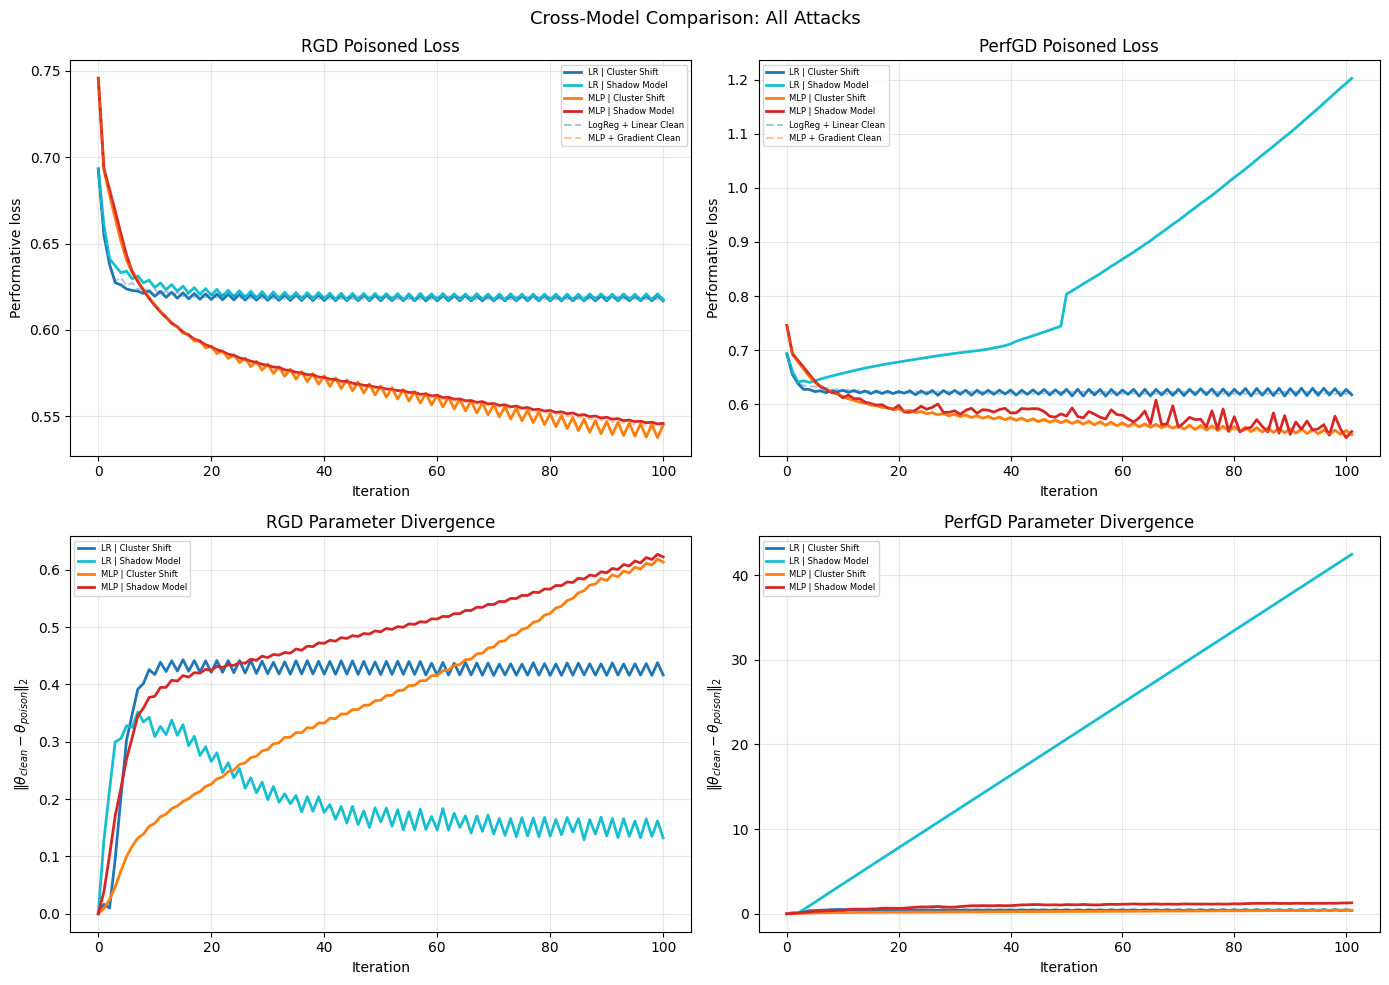

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

color_map = {
    "LogReg + Linear | Cluster Shift": "tab:blue",
    "LogReg + Linear | Shadow Model": "tab:cyan",
    "MLP + Gradient | Cluster Shift": "tab:orange",
    "MLP + Gradient | Shadow Model": "tab:red",
}

for key, res in results.items():
    c = color_map.get(key, "gray")
    short = key.replace("LogReg + Linear", "LR").replace("MLP + Gradient", "MLP")
    axes[0, 0].plot(res["rgd_poison_losses"], label=short, linewidth=2, color=c)
    axes[0, 1].plot(res["pgd_poison_losses"], label=short, linewidth=2, color=c)
    axes[1, 0].plot(res["rgd_divergence"], label=short, linewidth=2, color=c)
    axes[1, 1].plot(res["pgd_divergence"], label=short, linewidth=2, color=c)

# Add clean baselines
for model_name in models:
    first_key = [k for k in results if results[k]["model"] == model_name][0]
    res = results[first_key]
    c = "tab:blue" if "LogReg" in model_name else "tab:orange"
    axes[0, 0].plot(res["rgd_clean_losses"], linestyle="--", alpha=0.4, color=c, label=f"{model_name} Clean")
    axes[0, 1].plot(res["pgd_clean_losses"], linestyle="--", alpha=0.4, color=c, label=f"{model_name} Clean")

axes[0, 0].set_title("RGD Poisoned Loss"); axes[0, 0].set_ylabel("Performative loss")
axes[0, 1].set_title("PerfGD Poisoned Loss"); axes[0, 1].set_ylabel("Performative loss")
axes[1, 0].set_title("RGD Parameter Divergence"); axes[1, 0].set_ylabel(r"$\|\theta_{clean} - \theta_{poison}\|_2$")
axes[1, 1].set_title("PerfGD Parameter Divergence"); axes[1, 1].set_ylabel(r"$\|\theta_{clean} - \theta_{poison}\|_2$")
for ax in axes.flat:
    ax.set_xlabel("Iteration"); ax.legend(fontsize=6); ax.grid(True, alpha=0.3)

plt.suptitle("Cross-Model Comparison: All Attacks", fontsize=13)
plt.tight_layout()
plt.show()

## Classification Accuracy: Clean vs Poisoned

Accuracy gives a more direct comparison of how each poisoning method changes predictive performance, beyond loss and parameter displacement.


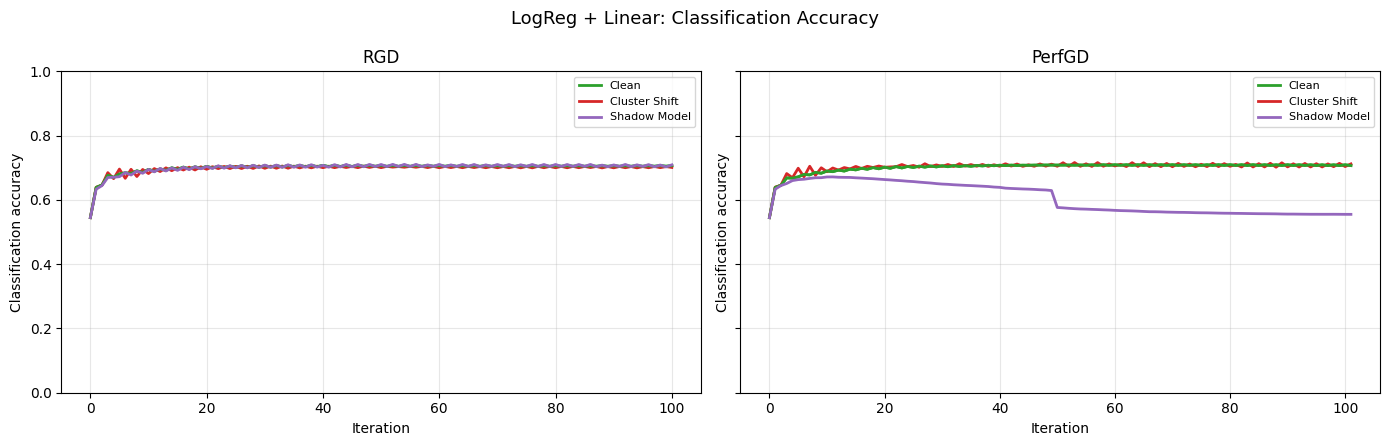

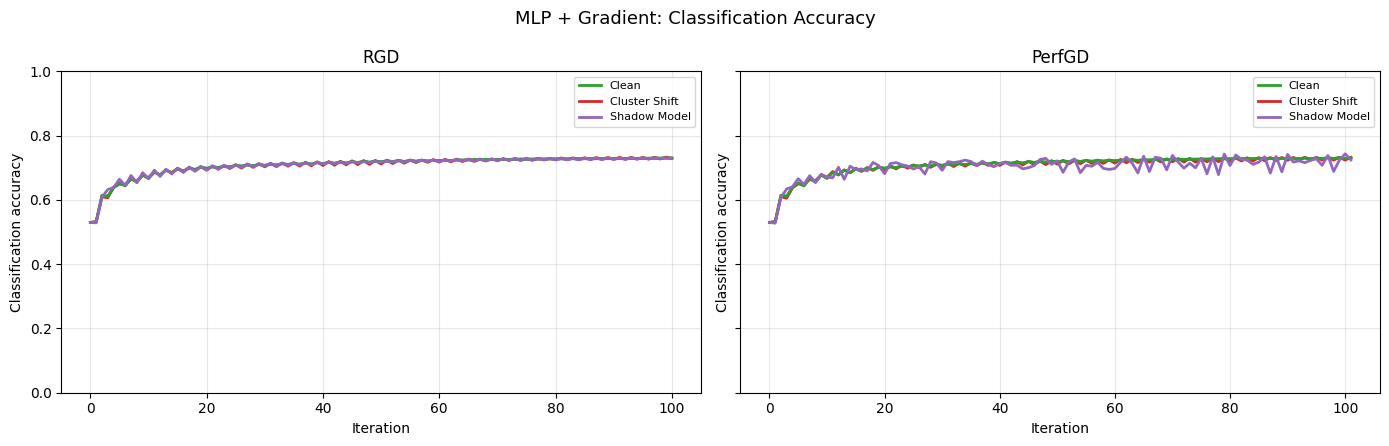

In [26]:
for model_name in models:
    model_results = {k: v for k, v in results.items() if v["model"] == model_name}
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
    fig.suptitle(f"{model_name}: Classification Accuracy", fontsize=13)
    attack_colors = {"Cluster Shift": "tab:red", "Shadow Model": "tab:purple"}

    for res in model_results.values():
        attack = res["attack"]
        c = attack_colors[attack]
        first = attack == "Cluster Shift"
        axes[0].plot(res["rgd_clean_accs"], color="tab:green", linewidth=2,
                     label="Clean" if first else None)
        axes[0].plot(res["rgd_poison_accs"], color=c, linewidth=2, label=attack)
        axes[1].plot(res["pgd_clean_accs"], color="tab:green", linewidth=2,
                     label="Clean" if first else None)
        axes[1].plot(res["pgd_poison_accs"], color=c, linewidth=2, label=attack)

    axes[0].set_title("RGD")
    axes[1].set_title("PerfGD")
    for ax in axes:
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Classification accuracy")
        ax.set_ylim(0, 1)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Summary Table

In [27]:
print(f"{'Key':<40} {'Algo':<8} {'Clean Loss':>11} {'Poison Loss':>12} {'Delta Loss':>11} {'Clean Acc':>10} {'Poison Acc':>10} {'Divergence':>11}")
print("-" * 122)
for key, res in results.items():
    for algo, cl, pl, clean_acc, poison_acc, div in [
        ("RGD", res["rgd_clean_losses"][-1], res["rgd_poison_losses"][-1], res["rgd_clean_accs"][-1], res["rgd_poison_accs"][-1], res["rgd_divergence"][-1]),
        ("PerfGD", res["pgd_clean_losses"][-1], res["pgd_poison_losses"][-1], res["pgd_clean_accs"][-1], res["pgd_poison_accs"][-1], res["pgd_divergence"][-1]),
    ]:
        print(f"{key:<40} {algo:<8} {cl:>11.4f} {pl:>12.4f} {pl-cl:>+11.4f} {clean_acc:>10.4f} {poison_acc:>10.4f} {div:>11.4f}")


Key                                      Algo      Clean Loss  Poison Loss  Delta Loss  Clean Acc Poison Acc  Divergence
--------------------------------------------------------------------------------------------------------------------------
LogReg + Linear | Cluster Shift          RGD           0.6193       0.6169     -0.0024     0.7064     0.7009      0.4166
LogReg + Linear | Cluster Shift          PerfGD        0.6231       0.6174     -0.0058     0.7068     0.7120      0.3893
LogReg + Linear | Shadow Model           RGD           0.6193       0.6175     -0.0018     0.7064     0.7090      0.1324
LogReg + Linear | Shadow Model           PerfGD        0.6231       1.2025     +0.5794     0.7068     0.5550     42.4478
MLP + Gradient | Cluster Shift           RGD           0.5448       0.5449     +0.0001     0.7302     0.7287      0.6134
MLP + Gradient | Cluster Shift           PerfGD        0.5442       0.5437     -0.0005     0.7315     0.7326      0.4117
MLP + Gradient | Shadow Model 

## Delta Sweep: Both Models

In [28]:
delta_vals = np.linspace(0.0, 3.0, 13)
sweep_results = {}

for d_val in delta_vals:
    print(f"robust delta = {d_val:.2f}", end="")

    for attack_name, attack_fn in [("Cluster", cluster_shift_attack), ("Shadow", shadow_model_attack)]:
        extra = {"shift_scale": 10.0} if attack_name == "Shadow" else {}
        sweep_fn = make_strategic_poison(
            attack_fn=attack_fn, strat_features=strat_features.tolist(),
            epsilon=poison_epsilon, delta=make_poison_delta_by_feature(d_val), selection="per_class",
            quantization_steps=response_quantization_steps,
            quantization_max_delta=response_max_delta, min_values=response_min_values, **extra)

        for model_name, m in models.items():
            key = f"{model_name} | {attack_name}"
            if key not in sweep_results:
                sweep_results[key] = {
                    "rgd_losses": [], "pgd_losses": [],
                    "rgd_divs": [], "pgd_divs": [],
                    "rgd_accs": [], "pgd_accs": [],
                }

            th_r, _, losses_r = RGD(
                D_theta=m["D_theta"], loss=m["loss"], theta_0=m["theta_0"].clone(),
                n=n, eta=m["eta"], max_iter=max_iter, proj_theta=proj_theta,
                return_losses=True, poison_function=sweep_fn)
            first_key = [k for k in results if results[k]["model"] == model_name][0]
            sweep_results[key]["rgd_losses"].append(losses_r[-1])
            sweep_results[key]["rgd_divs"].append(
                torch.norm(results[first_key]["rgd_clean_theta"] - th_r).item())
            sweep_results[key]["rgd_accs"].append(
                compute_accuracy(th_r, m["D_theta"], m["classifier"], m["hidden_dims"], d, n))

            th_p, _, losses_p = PerfGD(
                f_hat=m["f_hat"], grad2_est=m["grad2_est"], D_theta=m["D_theta"], loss=m["loss"],
                theta_0=m["theta_0"].clone(), n=n, eta=m["eta"], max_iter=max_iter,
                proj_theta=proj_theta, return_losses=True, poison_function=sweep_fn)
            sweep_results[key]["pgd_losses"].append(losses_p[-1])
            sweep_results[key]["pgd_divs"].append(
                torch.norm(results[first_key]["pgd_clean_theta"] - th_p).item())
            sweep_results[key]["pgd_accs"].append(
                compute_accuracy(th_p, m["D_theta"], m["classifier"], m["hidden_dims"], d, n))

    print(f" done")

print("Sweep done.")


robust delta = 0.00 done
robust delta = 0.25 done
robust delta = 0.50 done
robust delta = 0.75 done
robust delta = 1.00 done
robust delta = 1.25 done
robust delta = 1.50 done
robust delta = 1.75 done
robust delta = 2.00 done
robust delta = 2.25 done
robust delta = 2.50 done
robust delta = 2.75 done
robust delta = 3.00 done
Sweep done.


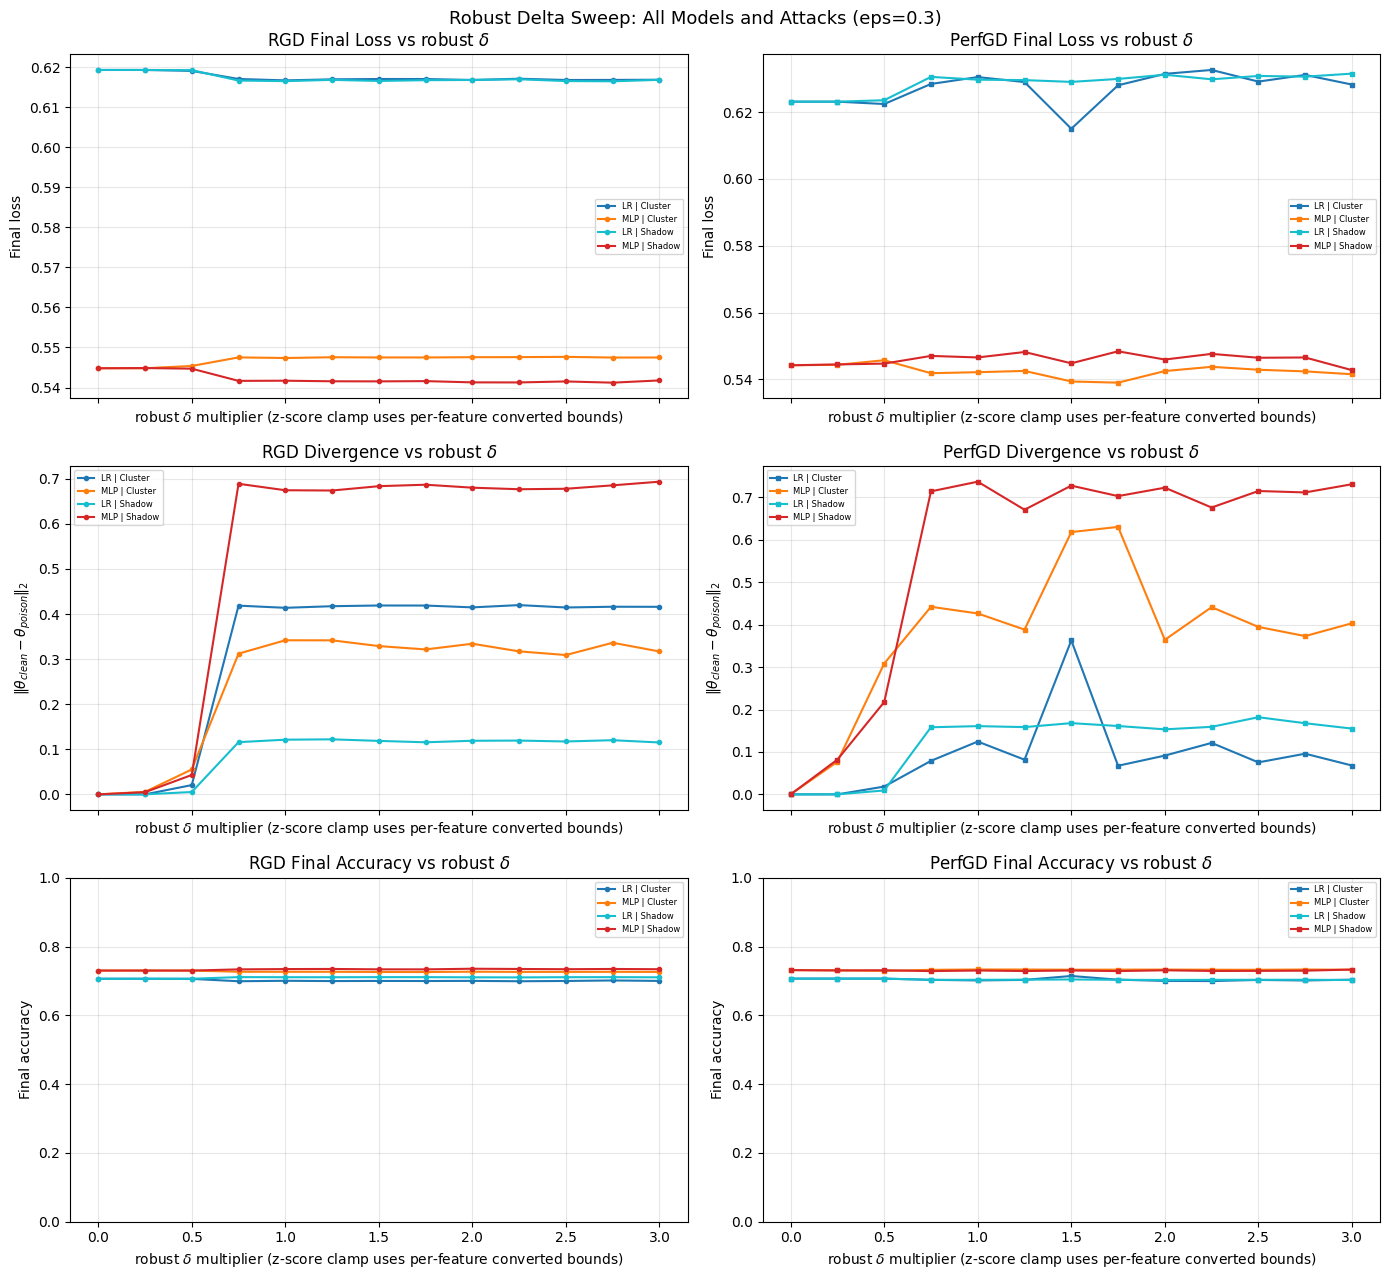

In [29]:
color_map = {
    "LogReg + Linear | Cluster": "tab:blue",
    "LogReg + Linear | Shadow": "tab:cyan",
    "MLP + Gradient | Cluster": "tab:orange",
    "MLP + Gradient | Shadow": "tab:red",
}

fig, axes = plt.subplots(3, 2, figsize=(14, 13), sharex=True)

for key, sr in sweep_results.items():
    c = color_map.get(key, "gray")
    short = key.replace("LogReg + Linear", "LR").replace("MLP + Gradient", "MLP")
    axes[0, 0].plot(delta_vals, sr["rgd_losses"], marker="o", markersize=3, label=short, color=c)
    axes[0, 1].plot(delta_vals, sr["pgd_losses"], marker="s", markersize=3, label=short, color=c)
    axes[1, 0].plot(delta_vals, sr["rgd_divs"], marker="o", markersize=3, label=short, color=c)
    axes[1, 1].plot(delta_vals, sr["pgd_divs"], marker="s", markersize=3, label=short, color=c)
    axes[2, 0].plot(delta_vals, sr["rgd_accs"], marker="o", markersize=3, label=short, color=c)
    axes[2, 1].plot(delta_vals, sr["pgd_accs"], marker="s", markersize=3, label=short, color=c)

axes[0, 0].set_title(r"RGD Final Loss vs robust $\delta$"); axes[0, 0].set_ylabel("Final loss")
axes[0, 1].set_title(r"PerfGD Final Loss vs robust $\delta$"); axes[0, 1].set_ylabel("Final loss")
axes[1, 0].set_title(r"RGD Divergence vs robust $\delta$"); axes[1, 0].set_ylabel(r"$\|\theta_{clean} - \theta_{poison}\|_2$")
axes[1, 1].set_title(r"PerfGD Divergence vs robust $\delta$"); axes[1, 1].set_ylabel(r"$\|\theta_{clean} - \theta_{poison}\|_2$")
axes[2, 0].set_title(r"RGD Final Accuracy vs robust $\delta$"); axes[2, 0].set_ylabel("Final accuracy")
axes[2, 1].set_title(r"PerfGD Final Accuracy vs robust $\delta$"); axes[2, 1].set_ylabel("Final accuracy")
axes[2, 0].set_ylim(0, 1)
axes[2, 1].set_ylim(0, 1)

for ax in axes.flat:
    ax.set_xlabel(r"robust $\delta$ multiplier (z-score clamp uses per-feature converted bounds)")
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Robust Delta Sweep: All Models and Attacks (eps={poison_epsilon})", fontsize=13)
plt.tight_layout()
plt.show()


## Enhanced Strategic Features

Feature 0 (`RevolvingUtilizationOfUnsecuredLines`) is the only informative strategic feature — features 1 and 2 have nearly identical class distributions. We inject class-conditional Gaussian offsets into features 1 and 2 to make all three strategic dimensions separable, then run the full experiment pipeline again and compare results.

**Hypothesis:** if the collapses / weak poisoning effects observed above are due to the problem being effectively 1D, the enhanced 3D version should show meaningfully different behaviour.

In [30]:
# Configuration: class-conditional integer offsets for the count-valued strategic features.
# strat_features[1] = NumberOfOpenCreditLinesAndLoans
# strat_features[2] = NumberRealEstateLoansOrLines
# Keys are local indices into strat_features; values are (offset_y0, offset_y1) in raw CSV counts.
# These are the nearest integer-count equivalents of the old standardized offsets.
enhance_standardized_offsets = {
    1: (-1.5, +1.5),
    2: (-1.0, +1.0),
}
enhance_count_offsets = {
    local_idx: (
        int(np.round(offset_y0 * raw_feature_stds[strat_features[local_idx]])),
        int(np.round(offset_y1 * raw_feature_stds[strat_features[local_idx]])),
    )
    for local_idx, (offset_y0, offset_y1) in enhance_standardized_offsets.items()
}

def make_enhanced_features(X, Y, sf, count_offsets):
    """Apply class-conditional integer shifts to count-valued strategic features.

    The model stores features as z-scores, but these enhanced shifts happen in
    original CSV units. For each count feature, we convert z -> raw count, round
    to an integer count, add an integer class-specific offset, clip at zero, and
    convert raw count -> z. RevolvingUtilizationOfUnsecuredLines is untouched.
    """
    X_enh = X.clone()
    y_np = Y.cpu().numpy().astype(int)
    for local_idx, (shift_y0, shift_y1) in count_offsets.items():
        col = sf[local_idx]
        raw_vals = to_raw_feature_values(X[:, col].cpu().numpy(), col)
        raw_counts = np.rint(raw_vals).astype(int)
        shifts = np.where(y_np == 0, shift_y0, shift_y1)
        enhanced_counts = np.clip(raw_counts + shifts, 0, None)
        enhanced_z = (enhanced_counts - raw_feature_means[col]) / raw_feature_stds[col]
        X_enh[:, col] = torch.tensor(enhanced_z, dtype=torch.float32, device=X.device)
    return X_enh

X_enhanced = make_enhanced_features(X_full, Y_full, strat_features, enhance_count_offsets)

print("Enhanced integer count offsets:")
for local_idx, offsets in enhance_count_offsets.items():
    feature_name = data.columns[strat_features[local_idx] + 1]
    print(f"  {feature_name}: y=0 {offsets[0]:+d}, y=1 {offsets[1]:+d} raw counts")

# Print separation statistics on original CSV scales.
print(f"{'Feature':<42} {'--- Original ---':^30} {'--- Enhanced ---':^30}")
print(f"{'':42} {'mu_y0':>9} {'mu_y1':>9} {'|diff|':>8}    {'mu_y0':>9} {'mu_y1':>9} {'|diff|':>8}")
print("-" * 110)
for i, col in enumerate(strat_features):
    fname = data.columns[col + 1][:40]
    orig_raw = to_raw_feature_values(X_full[:, col].cpu().numpy(), col)
    enh_raw = to_raw_feature_values(X_enhanced[:, col].cpu().numpy(), col)
    y_np = Y_full.cpu().numpy().astype(int)
    m0o = orig_raw[y_np == 0].mean()
    m1o = orig_raw[y_np == 1].mean()
    m0e = enh_raw[y_np == 0].mean()
    m1e = enh_raw[y_np == 1].mean()
    print(f"  [{i}] {fname:<40} {m0o:>+9.3f} {m1o:>+9.3f} {abs(m0o-m1o):>8.3f}    "
          f"{m0e:>+9.3f} {m1e:>+9.3f} {abs(m0e-m1e):>8.3f}")


Enhanced integer count offsets:
  NumberOfOpenCreditLinesAndLoans: y=0 -8, y=1 +8 raw counts
  NumberRealEstateLoansOrLines: y=0 -1, y=1 +1 raw counts
Feature                                           --- Original ---               --- Enhanced ---       
                                               mu_y0     mu_y1   |diff|        mu_y0     mu_y1   |diff|
--------------------------------------------------------------------------------------------------------------
  [0] RevolvingUtilizationOfUnsecuredLines        +4.452    +3.656    0.796       +4.452    +3.656    0.796
  [1] NumberOfOpenCreditLinesAndLoans             +8.763    +8.239    0.524       +2.291   +16.239   13.948
  [2] NumberRealEstateLoansOrLines                +1.051    +1.042    0.010       +0.402    +2.042    1.639


### Cluster Distributions (Original vs Enhanced)

Histograms of the three strategic features colored by class label, before any strategic best-response. Feature 0 (`RevolvingUtilizationOfUnsecuredLines`) is already informative; features 1 and 2 gain class-conditional Gaussian offsets under the Enhanced setting.

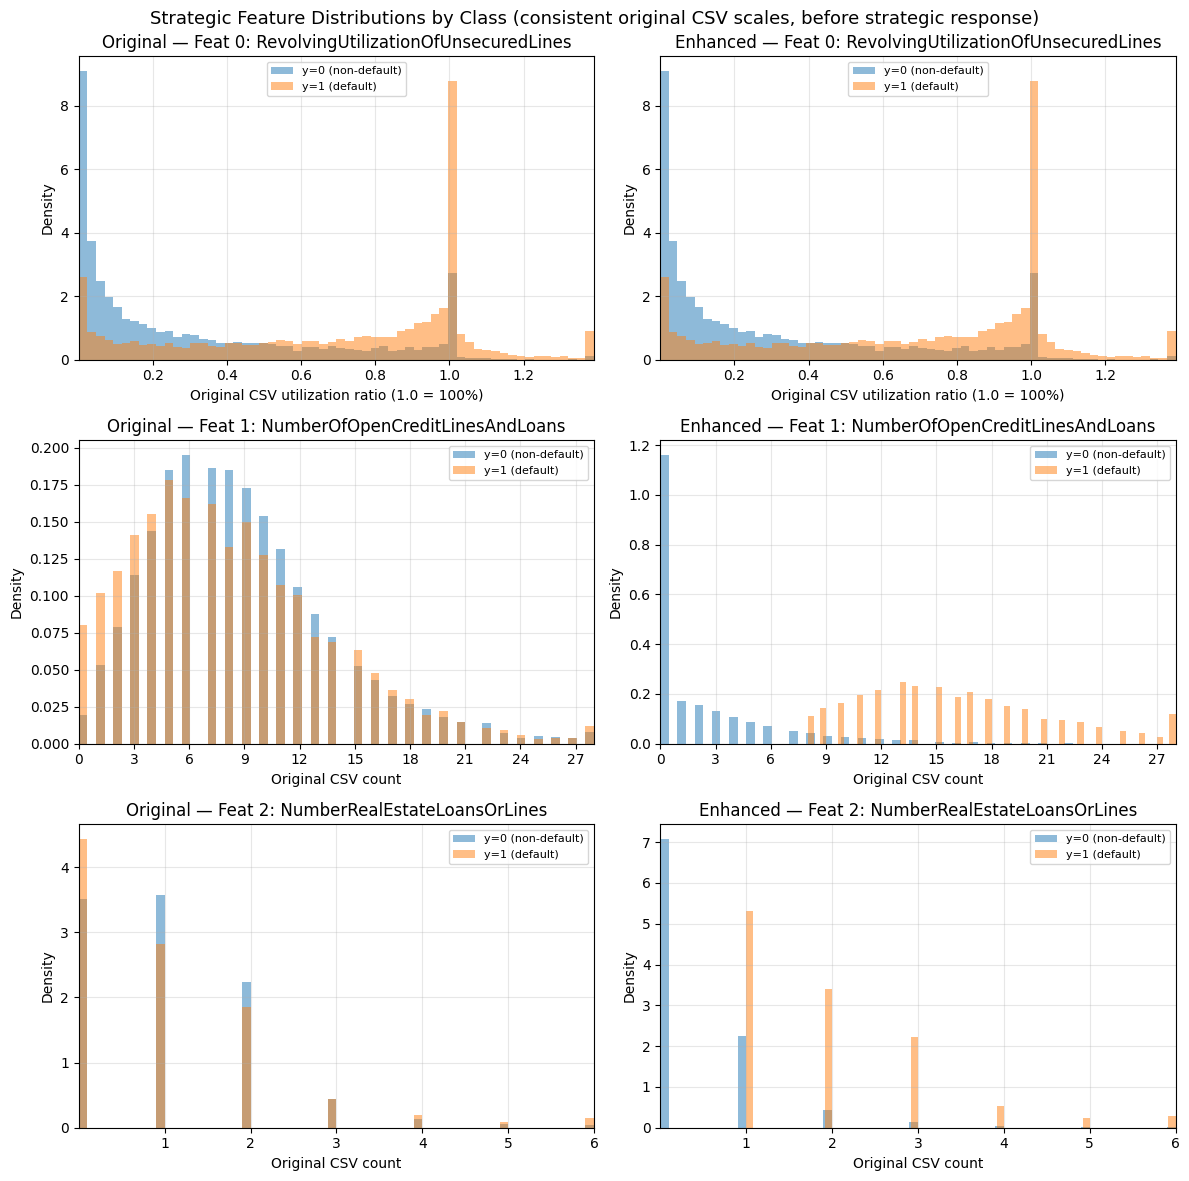

In [31]:
fig, axes = plt.subplots(len(strat_features), 2, figsize=(12, 4 * len(strat_features)))

for ri, col in enumerate(strat_features):
    fname = data.columns[col + 1]
    row_values = []
    for X_data in [X_full, X_enhanced]:
        row_values.append(to_raw_feature_values(X_data[Y_full == 0, col].numpy(), col))
        row_values.append(to_raw_feature_values(X_data[Y_full == 1, col].numpy(), col))
    row_lo, row_hi = np.percentile(np.concatenate(row_values), [1, 99])
    if data.columns[col + 1] == "RevolvingUtilizationOfUnsecuredLines":
        row_lo = max(row_lo, 0.0)

    for ci, (X_data, title) in enumerate([(X_full, "Original"), (X_enhanced, "Enhanced")]):
        ax = axes[ri, ci]
        x0 = to_raw_feature_values(X_data[Y_full == 0, col].numpy(), col)
        x1 = to_raw_feature_values(X_data[Y_full == 1, col].numpy(), col)
        ax.hist(np.clip(x0, row_lo, row_hi), bins=60, alpha=0.5, label='y=0 (non-default)',
                color='tab:blue', density=True)
        ax.hist(np.clip(x1, row_lo, row_hi), bins=60, alpha=0.5, label='y=1 (default)',
                color='tab:orange', density=True)
        ax.set_xlim(row_lo, row_hi)
        ax.set_title(f"{title} — Feat {ri}: {fname}")
        ax.set_xlabel(feature_axis_label(col)); ax.set_ylabel("Density")
        set_feature_axis_format(ax, col)
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle("Strategic Feature Distributions by Class (consistent original CSV scales, before strategic response)", fontsize=13)
plt.tight_layout(); plt.show()


### Model Setup for Enhanced Data

In [32]:
lam_enh = 1.0 / n_samples

(mu_f_lr_enh, sigma_lr_enh, D_theta_lr_enh,
 loss_lr_enh, theta_0_lr_enh, grad2_est_lr_enh, f_hat_lr_enh) = setup_strategic_classification(
    X_base=X_enhanced, Y_base=Y_full, strat_features=strat_features.tolist(),
    alpha=alpha_strat, lam=lam_enh, classifier="logreg", performativity="linear", perfGD=True,
    response_quantization_steps=response_quantization_steps, response_max_delta=response_max_delta,
    response_min_values=response_min_values,
)

(mu_f_mlp_enh, sigma_mlp_enh, D_theta_mlp_enh,
 loss_mlp_enh, theta_0_mlp_enh, grad2_est_mlp_enh, f_hat_mlp_enh) = setup_strategic_classification(
    X_base=X_enhanced, Y_base=Y_full, strat_features=strat_features.tolist(),
    alpha=alpha_strat, lam=lam_enh, classifier="mlp", performativity="gradient",
    perfGD=True, hidden_dims=MLP_HIDDEN_DIMS,
    response_quantization_steps=response_quantization_steps, response_max_delta=response_max_delta,
    response_min_values=response_min_values,
)

models_enh = {
    "LogReg + Linear": {
        "D_theta": D_theta_lr_enh, "loss": loss_lr_enh, "theta_0": theta_0_lr_enh,
        "grad2_est": grad2_est_lr_enh, "f_hat": f_hat_lr_enh, "eta": eta_logreg,
        "classifier": "logreg", "hidden_dims": MLP_HIDDEN_DIMS,
    },
    "MLP + Gradient": {
        "D_theta": D_theta_mlp_enh, "loss": loss_mlp_enh, "theta_0": theta_0_mlp_enh,
        "grad2_est": grad2_est_mlp_enh, "f_hat": f_hat_mlp_enh, "eta": eta_mlp,
        "classifier": "mlp", "hidden_dims": MLP_HIDDEN_DIMS,
    },
}

print(f"LogReg + Linear (enhanced): {theta_0_lr_enh.numel()} params")
print(f"MLP + Gradient  (enhanced): {theta_0_mlp_enh.numel()} params")

LogReg + Linear (enhanced): 11 params
MLP + Gradient  (enhanced): 897 params


### Run Experiments: Enhanced Data

Same RGD / PerfGD clean + poisoned protocol, now on the enhanced feature set.

In [33]:
results_enh = {}

for model_name, m in models_enh.items():
    print(f"\n{'='*60}")
    print(f"  {model_name}  [ENHANCED]")
    print(f"{'='*60}")

    D_theta_fn = m["D_theta"]
    loss_fn    = m["loss"]
    theta_0    = m["theta_0"]
    eta        = m["eta"]

    print("  RGD Clean...", end=" ")
    th_rc, all_th_rc, losses_rc = RGD(
        D_theta=D_theta_fn, loss=loss_fn, theta_0=theta_0.clone(),
        n=n, eta=eta, max_iter=max_iter, proj_theta=proj_theta, return_losses=True)
    print(f"loss={losses_rc[-1]:.4f}")

    print("  PerfGD Clean...", end=" ")
    th_pc, all_th_pc, losses_pc = PerfGD(
        f_hat=m["f_hat"], grad2_est=m["grad2_est"], D_theta=D_theta_fn, loss=loss_fn,
        theta_0=theta_0.clone(), n=n, eta=eta, max_iter=max_iter,
        proj_theta=proj_theta, return_losses=True)
    print(f"loss={losses_pc[-1]:.4f}")

    theta0 = theta_0.detach().clone()

    for attack_name, poison_fn in attacks.items():
        key = f"{model_name} | {attack_name}"
        print(f"  {attack_name}:", end="")

        print(" RGD...", end="")
        th_rp, all_th_rp, losses_rp = RGD(
            D_theta=D_theta_fn, loss=loss_fn, theta_0=theta_0.clone(),
            n=n, eta=eta, max_iter=max_iter, proj_theta=proj_theta, return_losses=True,
            poison_function=poison_fn)
        print(f"{losses_rp[-1]:.4f}", end="")

        print(" PerfGD...", end="")
        th_pp, all_th_pp, losses_pp = PerfGD(
            f_hat=m["f_hat"], grad2_est=m["grad2_est"], D_theta=D_theta_fn, loss=loss_fn,
            theta_0=theta_0.clone(), n=n, eta=eta, max_iter=max_iter,
            proj_theta=proj_theta, return_losses=True,
            poison_function=poison_fn)
        print(f"{losses_pp[-1]:.4f}")

        results_enh[key] = {
            "model": model_name, "attack": attack_name,
            "rgd_clean_losses": losses_rc, "rgd_poison_losses": losses_rp,
            "pgd_clean_losses": losses_pc, "pgd_poison_losses": losses_pp,
            "rgd_clean_theta": th_rc.detach(), "rgd_poison_theta": th_rp.detach(),
            "pgd_clean_theta": th_pc.detach(), "pgd_poison_theta": th_pp.detach(),
            "all_theta_rgd_clean": all_th_rc, "all_theta_rgd_poison": all_th_rp,
            "all_theta_pgd_clean": all_th_pc, "all_theta_pgd_poison": all_th_pp,
            "theta_0": theta0,
            "rgd_clean_diffs": [(t - theta0).norm().item() for t in all_th_rc],
            "rgd_poison_diffs": [(t - theta0).norm().item() for t in all_th_rp],
            "pgd_clean_diffs": [(t - theta0).norm().item() for t in all_th_pc],
            "pgd_poison_diffs": [(t - theta0).norm().item() for t in all_th_pp],
            "rgd_divergence": [torch.norm(c - p).item() for c, p in zip(all_th_rc, all_th_rp)],
            "pgd_divergence": [torch.norm(c - p).item() for c, p in zip(all_th_pc, all_th_pp)],
            "rgd_clean_accs": [compute_accuracy(t, D_theta_fn, m["classifier"], m["hidden_dims"], d, n) for t in all_th_rc],
            "rgd_poison_accs": [compute_accuracy(t, D_theta_fn, m["classifier"], m["hidden_dims"], d, n) for t in all_th_rp],
            "pgd_clean_accs": [compute_accuracy(t, D_theta_fn, m["classifier"], m["hidden_dims"], d, n) for t in all_th_pc],
            "pgd_poison_accs": [compute_accuracy(t, D_theta_fn, m["classifier"], m["hidden_dims"], d, n) for t in all_th_pp],
        }

print("\nDone.")


  LogReg + Linear  [ENHANCED]
  RGD Clean... loss=0.1259
  PerfGD Clean... loss=1.5549
  Cluster Shift: RGD...0.1331 PerfGD...1.5644
  Shadow Model: RGD...0.1285 PerfGD...1.7327

  MLP + Gradient  [ENHANCED]
  RGD Clean... loss=0.0678
  PerfGD Clean... loss=0.0766
  Cluster Shift: RGD...0.1016 PerfGD...0.0981
  Shadow Model: RGD...0.1077 PerfGD...0.0908

Done.


### Cluster Visualization: Before & After Poisoning

Strategic feature distributions evaluated at the converged clean θ, comparing the honest best-response (Clean) vs each attack. Rows = strategic features; columns = Original/Enhanced × Clean/ClusterShift/ShadowModel.

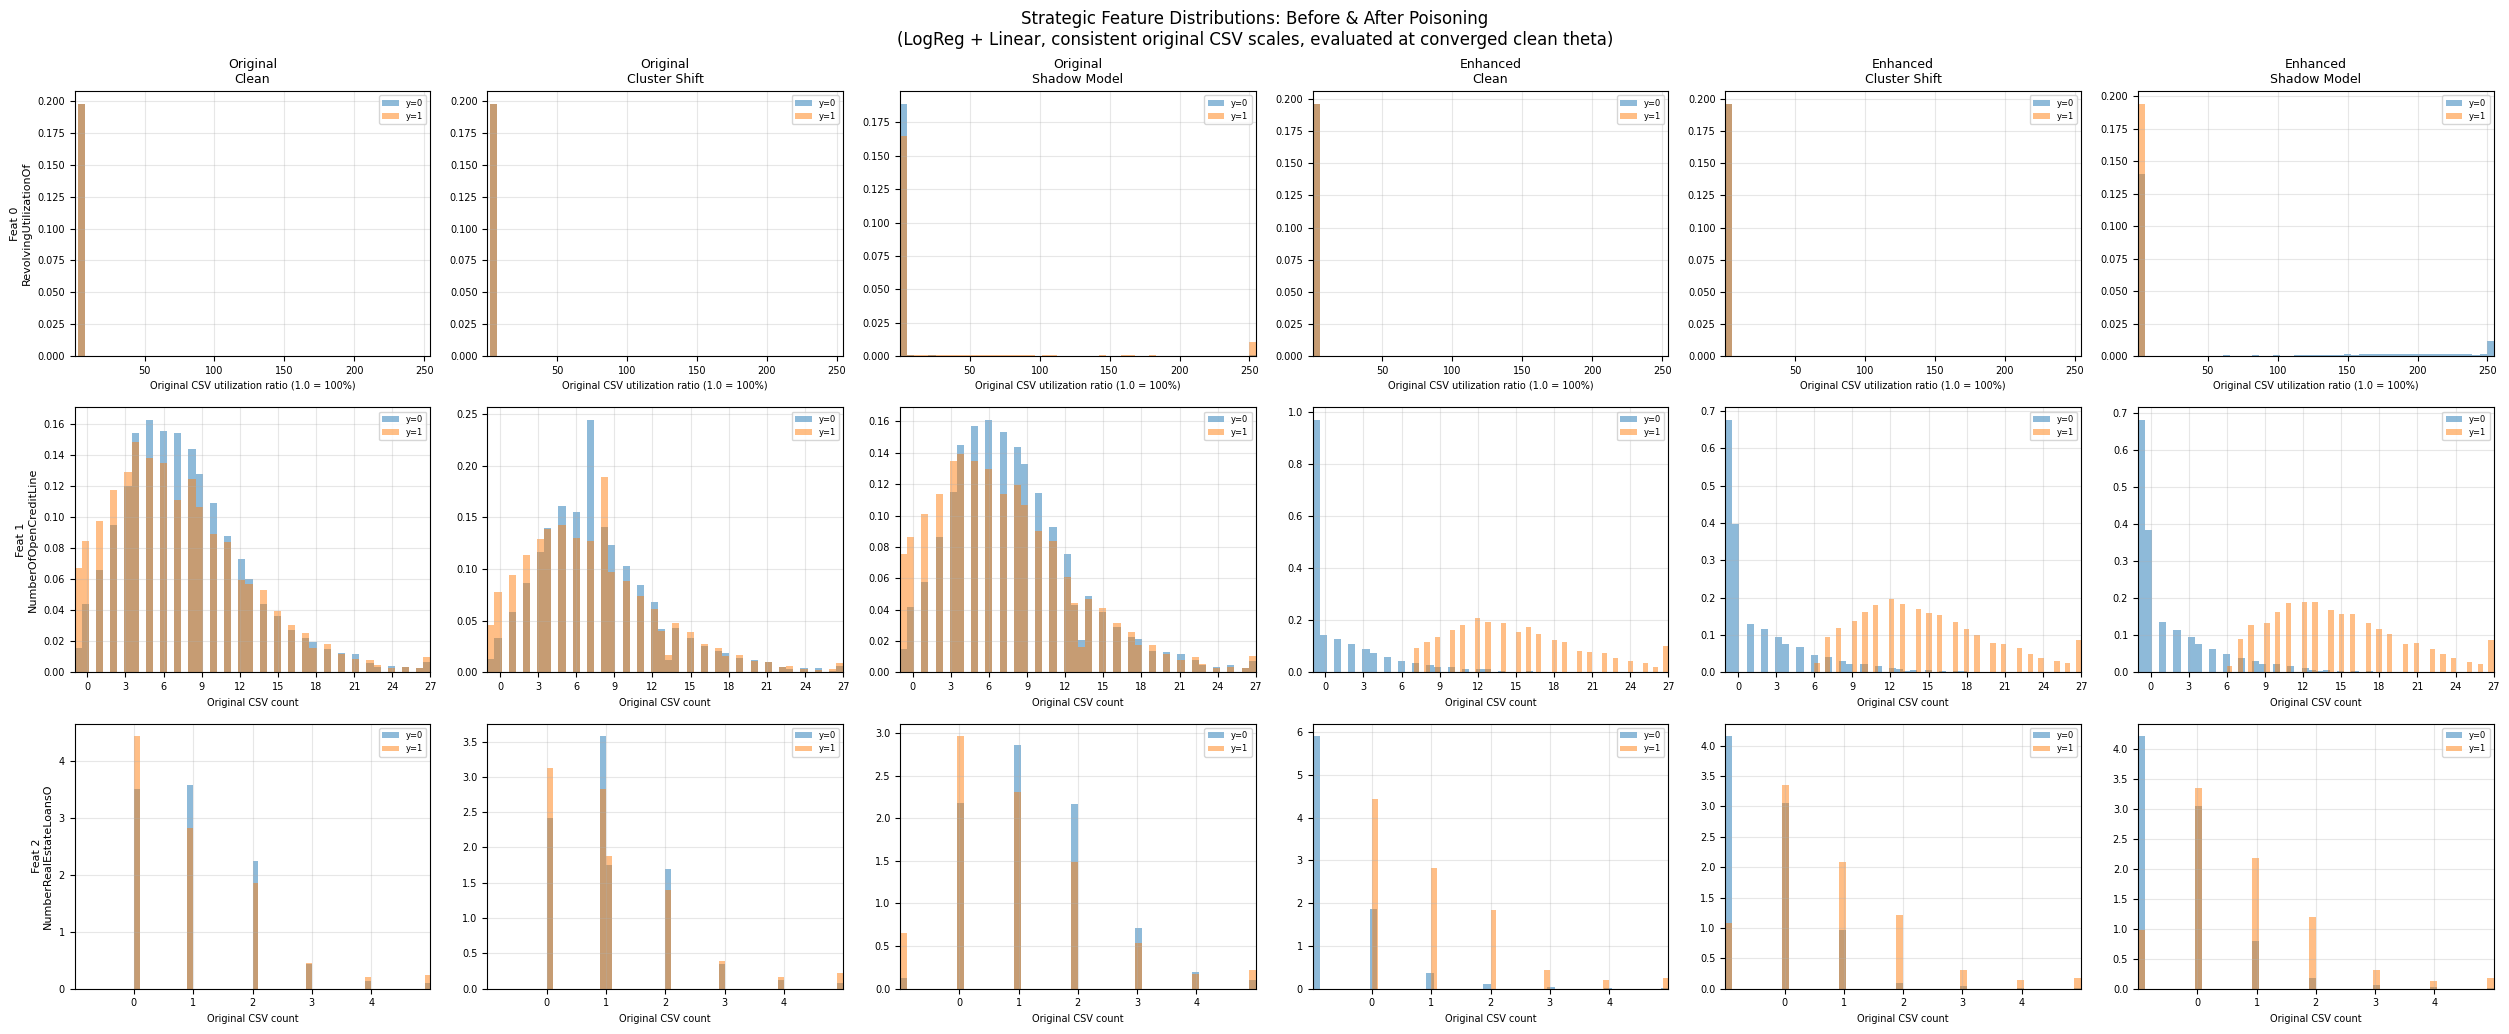


Configured poison_delta = 10000.0 robust/raw-count units
Per-feature z-score bounds used by the poisoning clamp:
  RevolvingUtilizationOfUnsecuredLines: +/-15.698615 z, +/-4035.166 utilization ratio (403516.6 percentage points)
  NumberOfOpenCreditLinesAndLoans: +/-0.193318 z, +/-1 raw count
  NumberRealEstateLoansOrLines: +/-0.870119 z, +/-1 raw count

Original Cluster Shift: max absolute poisoning shift by strategic feature
  RevolvingUtilizationOfUnsecuredLines: 15.6986 z-score units, 4035.166 utilization ratio (403516.6 percentage points)
  NumberOfOpenCreditLinesAndLoans: 0.1933 z-score units, 1.000 raw counts
  NumberRealEstateLoansOrLines: 0.8701 z-score units, 1.000 raw counts

Original Shadow Model: max absolute poisoning shift by strategic feature
  RevolvingUtilizationOfUnsecuredLines: 15.6986 z-score units, 4035.166 utilization ratio (403516.6 percentage points)
  NumberOfOpenCreditLinesAndLoans: 0.1933 z-score units, 1.000 raw counts
  NumberRealEstateLoansOrLines: 0.8701

In [34]:
# Use LogReg + Linear for interpretable cluster visualization.
# Evaluate at the converged clean RGD theta for each dataset.
theta_orig_lr = results["LogReg + Linear | Cluster Shift"]["rgd_clean_theta"]
theta_enh_lr  = results_enh["LogReg + Linear | Cluster Shift"]["rgd_clean_theta"]

with torch.no_grad():
    # n > n_total triggers full-batch path in D_theta (no random sampling)
    z_orig_clean   = D_theta_lr(theta_orig_lr, n_samples + 1)
    z_enh_clean    = D_theta_lr_enh(theta_enh_lr, n_samples + 1)

    z_orig_cluster = cluster_fn(z_orig_clean,  theta_orig_lr)
    z_orig_shadow  = shadow_fn(z_orig_clean,   theta_orig_lr)
    z_enh_cluster  = cluster_fn(z_enh_clean,   theta_enh_lr)
    z_enh_shadow   = shadow_fn(z_enh_clean,    theta_enh_lr)

def extract_strat_feats(z):
    idx_t = torch.tensor(strat_features, dtype=torch.long)
    return z[idx_t, :].T.numpy(), z[-1, :].numpy()

states_bap = {
    "Original\nClean":          extract_strat_feats(z_orig_clean),
    "Original\nCluster Shift":  extract_strat_feats(z_orig_cluster),
    "Original\nShadow Model":   extract_strat_feats(z_orig_shadow),
    "Enhanced\nClean":          extract_strat_feats(z_enh_clean),
    "Enhanced\nCluster Shift":  extract_strat_feats(z_enh_cluster),
    "Enhanced\nShadow Model":   extract_strat_feats(z_enh_shadow),
}

n_sf = len(strat_features)
n_st = len(states_bap)

fig, axes = plt.subplots(n_sf, n_st, figsize=(4.2 * n_st, 3.5 * n_sf))
for ri, sf_col in enumerate(strat_features):
    fname = data.columns[sf_col + 1]
    row_values = []
    for x_s, y_s in states_bap.values():
        row_values.append(to_raw_feature_values(x_s[y_s == 0, ri], sf_col))
        row_values.append(to_raw_feature_values(x_s[y_s == 1, ri], sf_col))
    row_lo, row_hi = np.percentile(np.concatenate(row_values), [1, 99])
    if data.columns[sf_col + 1] == "RevolvingUtilizationOfUnsecuredLines":
        row_lo = max(row_lo, 0.0)

    for ci, (state_lbl, (x_s, y_s)) in enumerate(states_bap.items()):
        ax = axes[ri, ci]
        x0 = to_raw_feature_values(x_s[y_s == 0, ri], sf_col)
        x1 = to_raw_feature_values(x_s[y_s == 1, ri], sf_col)
        ax.hist(np.clip(x0, row_lo, row_hi), bins=50, alpha=0.5, label='y=0',
                color='tab:blue', density=True)
        ax.hist(np.clip(x1, row_lo, row_hi), bins=50, alpha=0.5, label='y=1',
                color='tab:orange', density=True)
        ax.set_xlim(row_lo, row_hi)
        if ri == 0: ax.set_title(state_lbl, fontsize=9)
        if ci == 0: ax.set_ylabel(f"Feat {ri}\n{fname[:22]}", fontsize=8)
        ax.set_xlabel(feature_axis_label(sf_col), fontsize=7)
        set_feature_axis_format(ax, sf_col)
        ax.legend(fontsize=6); ax.grid(True, alpha=0.3); ax.tick_params(labelsize=7)

plt.suptitle("Strategic Feature Distributions: Before & After Poisoning\n"
             "(LogReg + Linear, consistent original CSV scales, evaluated at converged clean theta)", fontsize=12)
plt.tight_layout(); plt.show()


# Audit the poisoning bound in model space and raw display space.
# The Linf bound is enforced on z-scored values; raw deltas are shown only for interpretation.
def audit_poison_shift_bounds(clean_z, poisoned_z, label):
    clean_x = clean_z[torch.tensor(strat_features, dtype=torch.long), :].T.numpy()
    poison_x = poisoned_z[torch.tensor(strat_features, dtype=torch.long), :].T.numpy()
    dz = poison_x - clean_x
    print(f"\n{label}: max absolute poisoning shift by strategic feature")
    for ri, col in enumerate(strat_features):
        feature_name = data.columns[col + 1]
        max_z = np.max(np.abs(dz[:, ri]))
        max_raw = max_z * raw_feature_stds[col]
        if feature_name == "RevolvingUtilizationOfUnsecuredLines":
            print(f"  {feature_name}: {max_z:.4f} z-score units, "
                  f"{max_raw:.3f} utilization ratio ({100 * max_raw:.1f} percentage points)")
        elif ri in discrete_strat_local_idxs:
            print(f"  {feature_name}: {max_z:.4f} z-score units, {max_raw:.3f} raw counts")
        else:
            print(f"  {feature_name}: {max_z:.4f} z-score units, {max_raw:.3f} raw units")

print(f"\nConfigured poison_delta = {poison_delta} robust/raw-count units")
print("Per-feature z-score bounds used by the poisoning clamp:")
for ri, col in enumerate(strat_features):
    feature_name = data.columns[col + 1]
    z_delta = float(poison_delta_by_feature[ri])
    raw_delta = z_delta * raw_feature_stds[col]
    if feature_name == "RevolvingUtilizationOfUnsecuredLines":
        print(f"  {feature_name}: +/-{z_delta:.6f} z, +/-{raw_delta:.3f} utilization ratio "
              f"({100 * raw_delta:.1f} percentage points)")
    elif ri in discrete_strat_local_idxs:
        print(f"  {feature_name}: +/-{z_delta:.6f} z, +/-{raw_delta:.0f} raw count")
    else:
        print(f"  {feature_name}: +/-{z_delta:.6f} z, +/-{raw_delta:.3f} raw units")
audit_poison_shift_bounds(z_orig_clean, z_orig_cluster, "Original Cluster Shift")
audit_poison_shift_bounds(z_orig_clean, z_orig_shadow, "Original Shadow Model")
audit_poison_shift_bounds(z_enh_clean, z_enh_cluster, "Enhanced Cluster Shift")
audit_poison_shift_bounds(z_enh_clean, z_enh_shadow, "Enhanced Shadow Model")


### Loss & Convergence: Original vs Enhanced

Side-by-side comparison of loss curves and parameter displacement across algorithms and attacks. If the enhanced features reduce the "collapse" seen in the original experiments, this confirms the 1D nature of the problem.

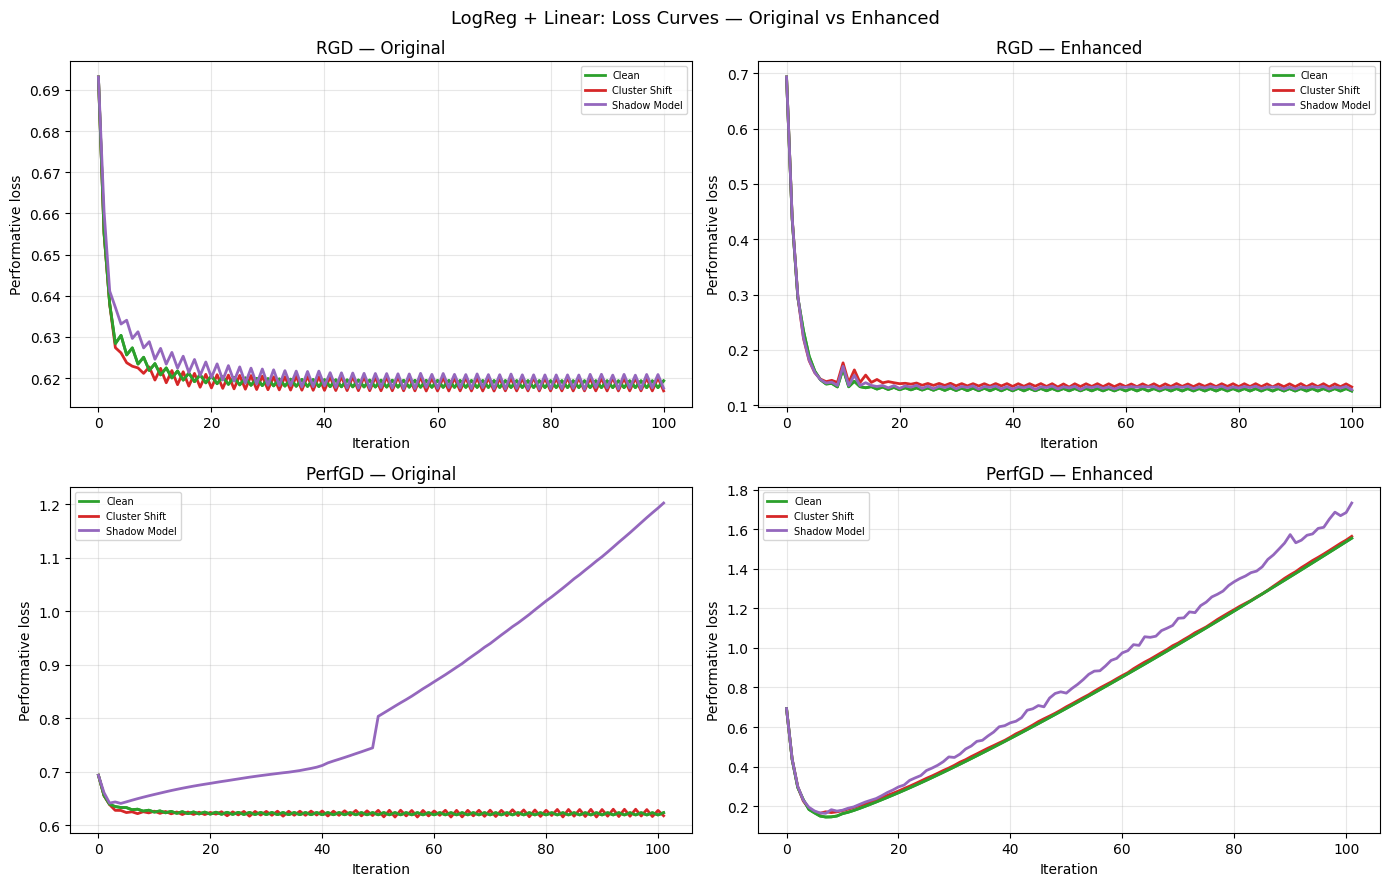

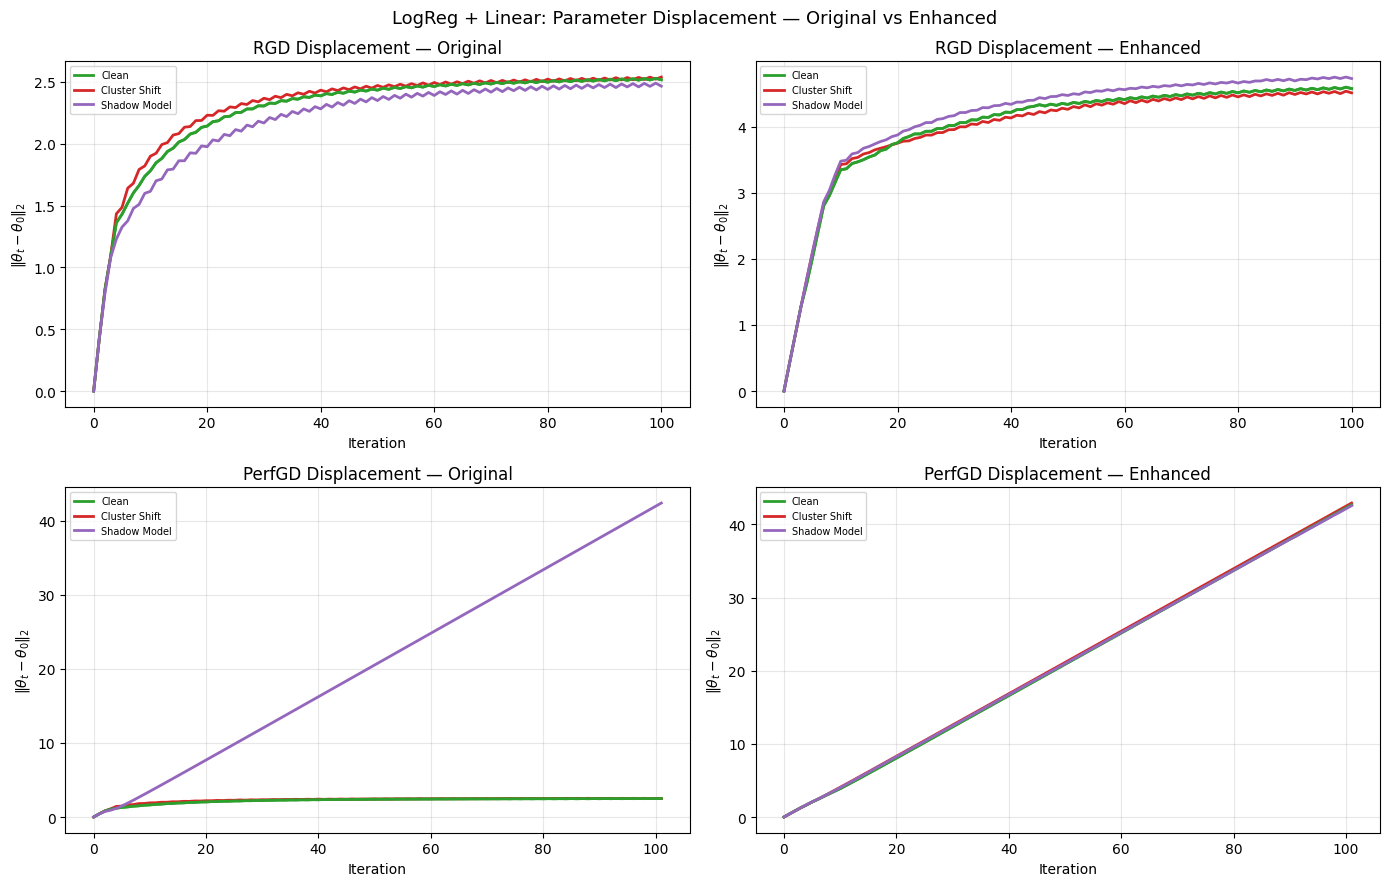

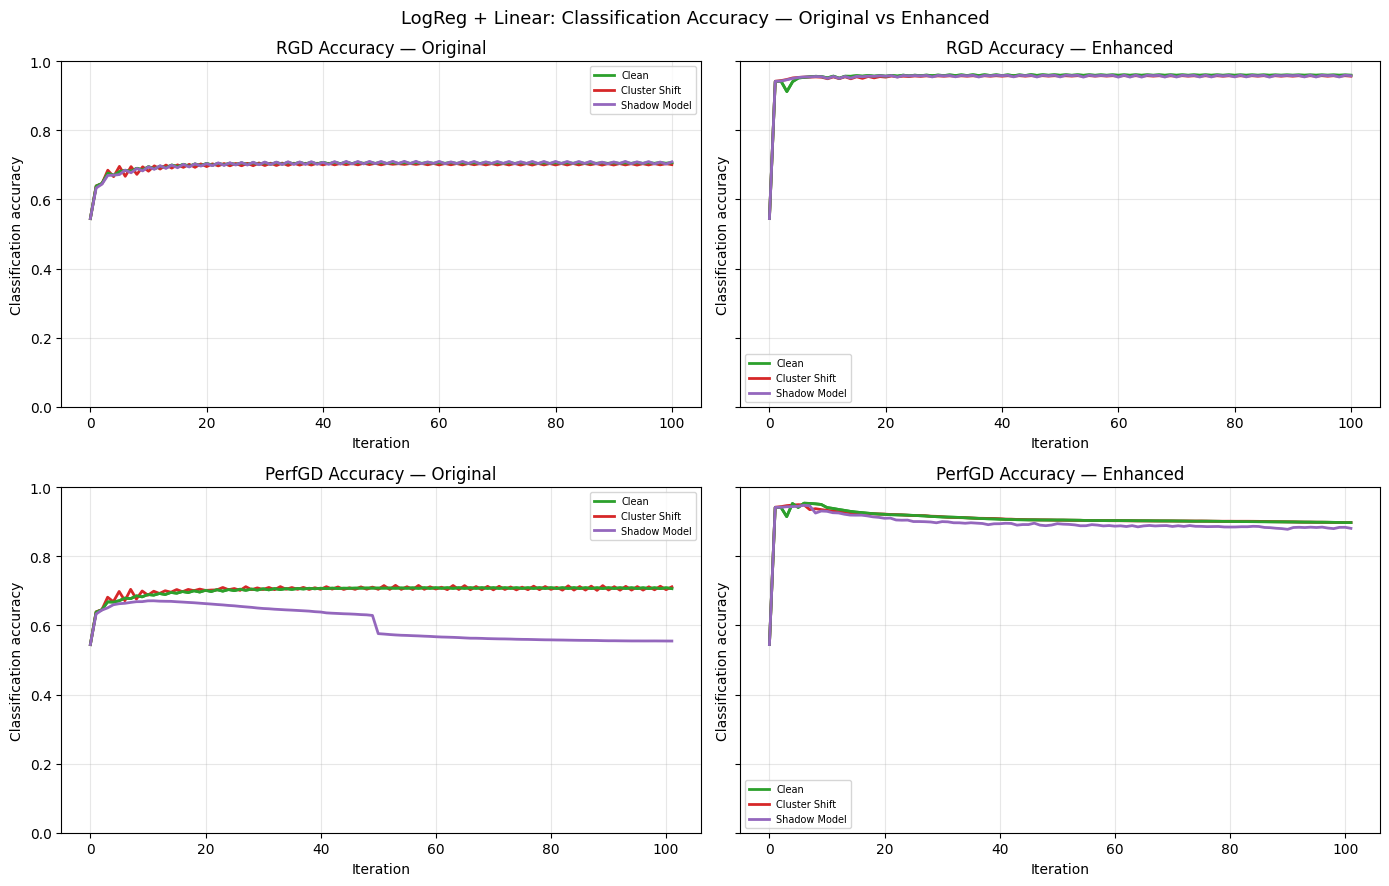

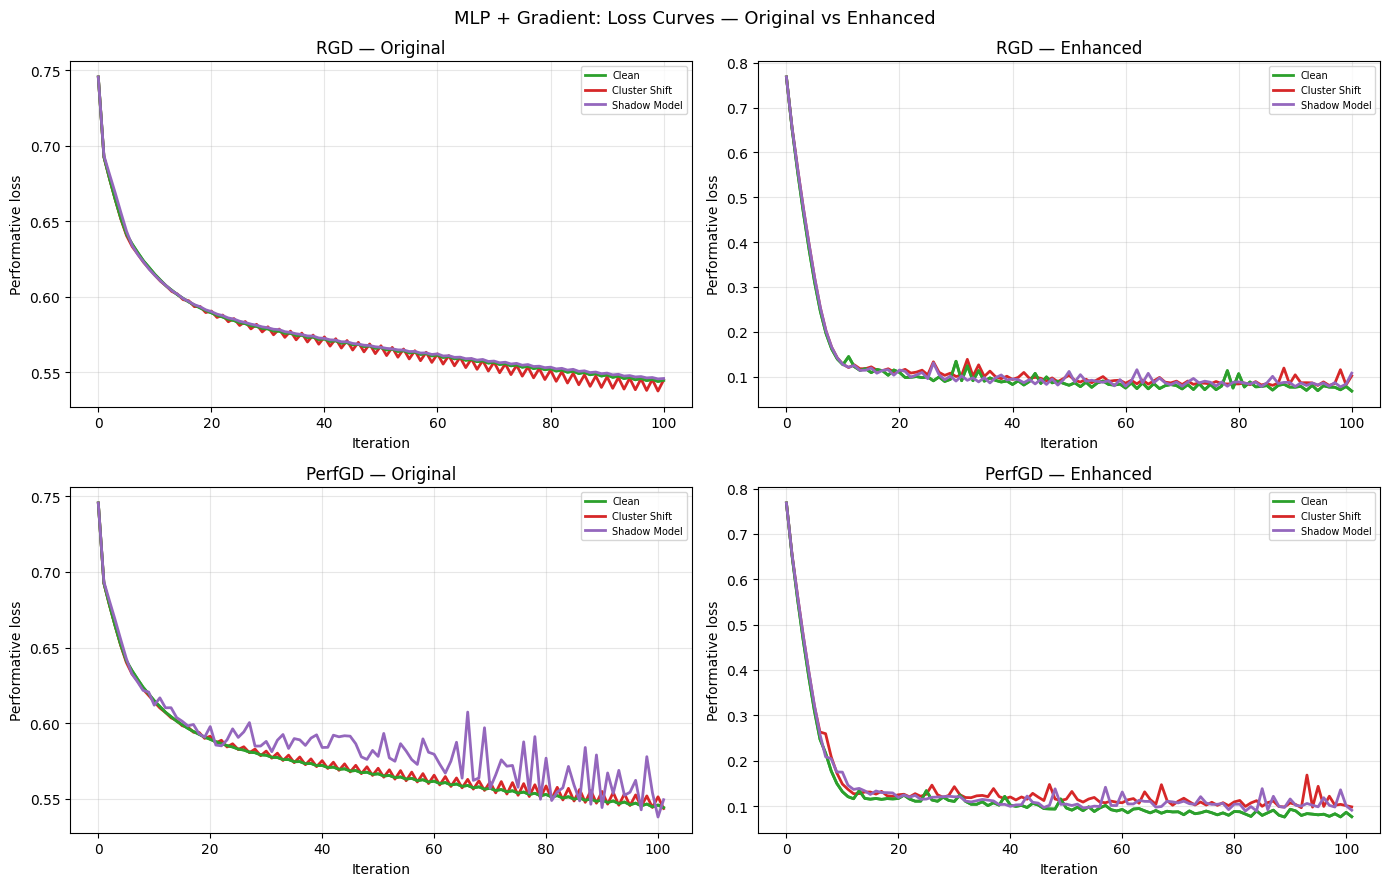

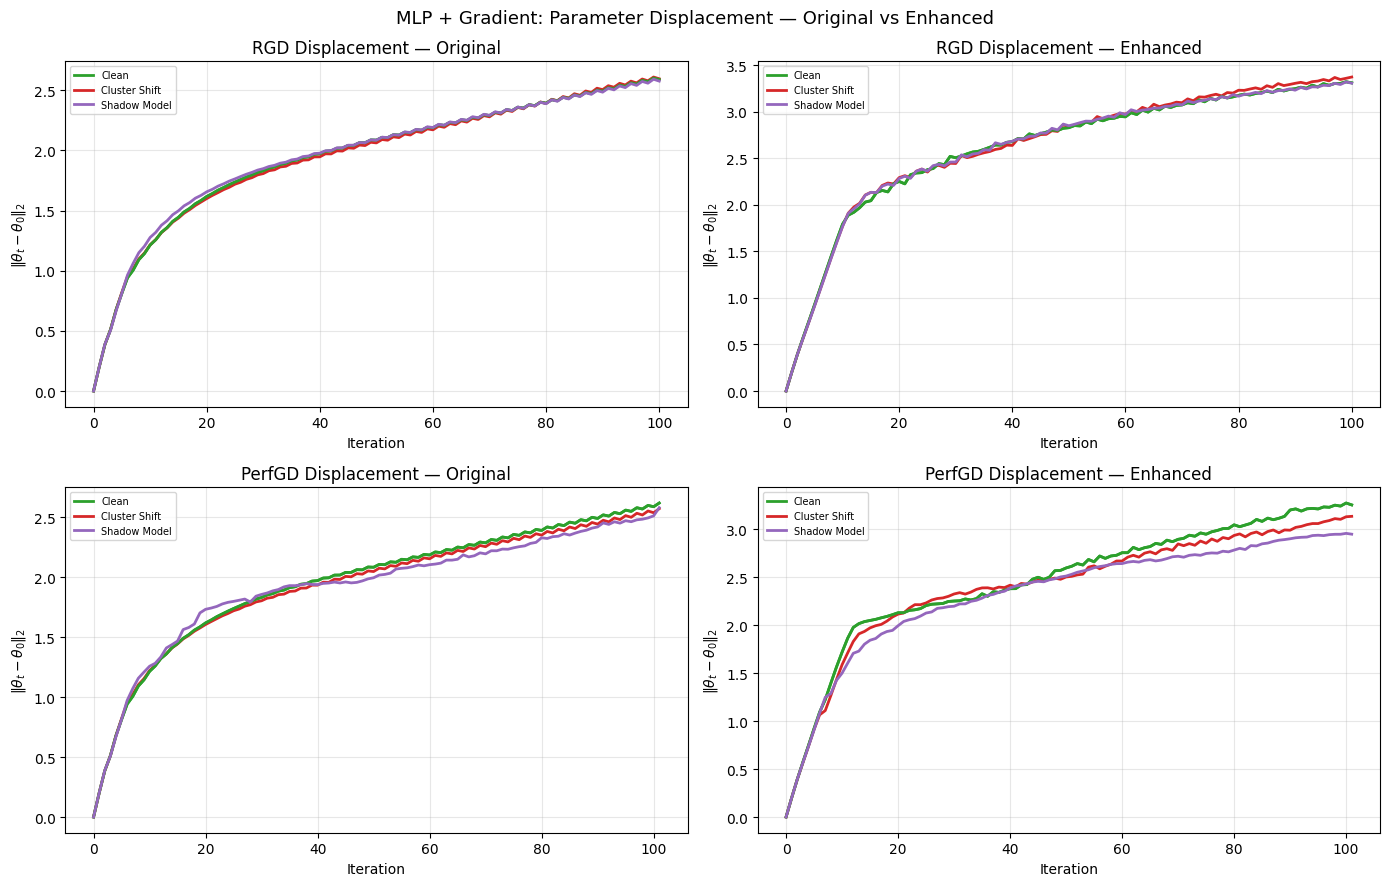

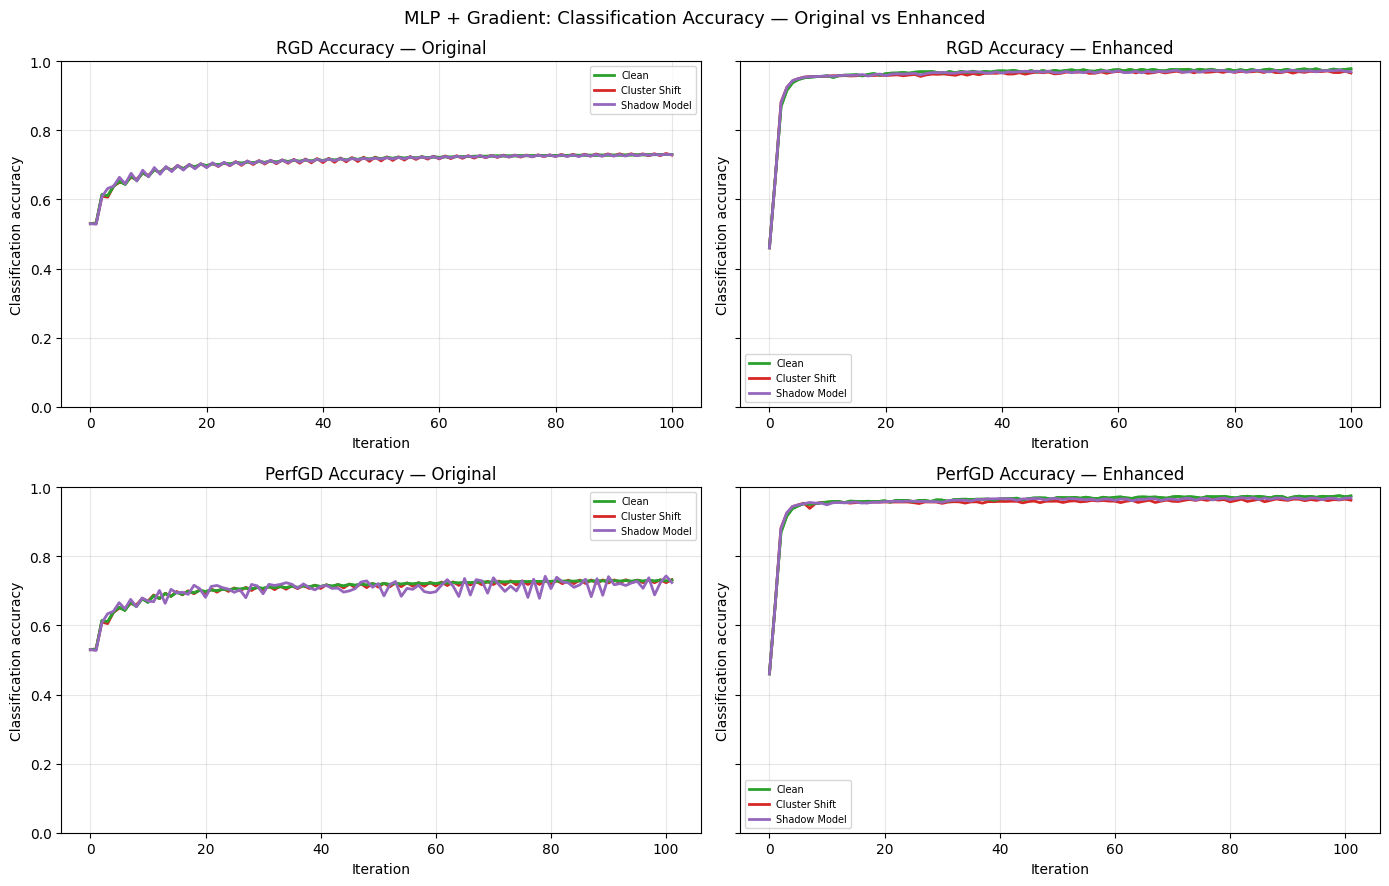

In [35]:
attack_colors_cmp = {"Cluster Shift": "tab:red", "Shadow Model": "tab:purple"}

for model_name in models:
    orig = {k: v for k, v in results.items() if v["model"] == model_name}
    enh  = {k: v for k, v in results_enh.items() if v["model"] == model_name}

    # --- Loss curves ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle(f"{model_name}: Loss Curves — Original vs Enhanced", fontsize=13)

    for col, (res_dict, lbl) in enumerate([(orig, "Original"), (enh, "Enhanced")]):
        first_attack = list(attacks.keys())[0]
        for key, res in res_dict.items():
            attack = res["attack"]
            c = attack_colors_cmp[attack]
            first = (attack == first_attack)
            axes[0, col].plot(res["rgd_clean_losses"], color="tab:green", linewidth=2,
                              label="Clean" if first else None)
            axes[0, col].plot(res["rgd_poison_losses"], color=c, linewidth=2, label=attack)
            axes[1, col].plot(res["pgd_clean_losses"], color="tab:green", linewidth=2,
                              label="Clean" if first else None)
            axes[1, col].plot(res["pgd_poison_losses"], color=c, linewidth=2, label=attack)
        axes[0, col].set_title(f"RGD — {lbl}")
        axes[1, col].set_title(f"PerfGD — {lbl}")

    for ax in axes.flat:
        ax.set_xlabel("Iteration"); ax.set_ylabel("Performative loss")
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    # --- Parameter displacement ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle(f"{model_name}: Parameter Displacement — Original vs Enhanced", fontsize=13)

    for col, (res_dict, lbl) in enumerate([(orig, "Original"), (enh, "Enhanced")]):
        first_attack = list(attacks.keys())[0]
        for key, res in res_dict.items():
            attack = res["attack"]
            c = attack_colors_cmp[attack]
            first = (attack == first_attack)
            axes[0, col].plot(res["rgd_clean_diffs"], color="tab:green", linewidth=2,
                              label="Clean" if first else None)
            axes[0, col].plot(res["rgd_poison_diffs"], color=c, linewidth=2, label=attack)
            axes[1, col].plot(res["pgd_clean_diffs"], color="tab:green", linewidth=2,
                              label="Clean" if first else None)
            axes[1, col].plot(res["pgd_poison_diffs"], color=c, linewidth=2, label=attack)
        axes[0, col].set_title(f"RGD Displacement — {lbl}")
        axes[1, col].set_title(f"PerfGD Displacement — {lbl}")

    for ax in axes.flat:
        ax.set_xlabel("Iteration"); ax.set_ylabel(r"$\|\theta_t - \theta_0\|_2$")
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    # --- Classification accuracy ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
    fig.suptitle(f"{model_name}: Classification Accuracy — Original vs Enhanced", fontsize=13)

    for col, (res_dict, lbl) in enumerate([(orig, "Original"), (enh, "Enhanced")]):
        first_attack = list(attacks.keys())[0]
        for key, res in res_dict.items():
            attack = res["attack"]
            c = attack_colors_cmp[attack]
            first = (attack == first_attack)
            axes[0, col].plot(res["rgd_clean_accs"], color="tab:green", linewidth=2,
                              label="Clean" if first else None)
            axes[0, col].plot(res["rgd_poison_accs"], color=c, linewidth=2, label=attack)
            axes[1, col].plot(res["pgd_clean_accs"], color="tab:green", linewidth=2,
                              label="Clean" if first else None)
            axes[1, col].plot(res["pgd_poison_accs"], color=c, linewidth=2, label=attack)
        axes[0, col].set_title(f"RGD Accuracy — {lbl}")
        axes[1, col].set_title(f"PerfGD Accuracy — {lbl}")

    for ax in axes.flat:
        ax.set_xlabel("Iteration"); ax.set_ylabel("Classification accuracy")
        ax.set_ylim(0, 1); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
